# ZeRO on 32 Virtual GPUs

**Train one small GPT on 32 virtual GPUs four ways (DDP, ZeRO-1, ZeRO-2, ZeRO-3) and
measure, byte by byte, what each GPU holds, sends and computes.**

Training a model with Adam in mixed precision costs **16 bytes per parameter** before a
single activation is stored: 2 (bf16 weights) + 2 (bf16 gradients) + 12 (fp32 master
copy, Adam momentum, Adam variance). Plain data parallelism (DDP) keeps all 16 bytes on
*every* GPU, so adding GPUs adds speed but never room. ZeRO removes that duplication
one piece at a time:

```text
                    GPU0     GPU1     GPU2     GPU3        (■ = holds that quarter)
DDP (ZeRO-0)  W    ■■■■     ■■■■     ■■■■     ■■■■
              G    ■■■■     ■■■■     ■■■■     ■■■■
              OS   ■■■■     ■■■■     ■■■■     ■■■■
ZeRO-1        OS   ■···     ·■··     ··■·     ···■     ← optimizer states split
ZeRO-2        G    ■···     ·■··     ··■·     ···■     ← + gradients split
ZeRO-3        W    ■···     ·■··     ··■·     ···■     ← + weights split (gathered just in time)
W = weights 2Ψ   G = gradients 2Ψ   OS = optimizer states 12Ψ   (Ψ = number of parameters)
```

Nothing here is simulated by formula alone. Every virtual GPU keeps a **ledger** of the
buffers it really holds; the collectives really move tensors between threads; the
optimizer really updates only its slice. The formulas from the ZeRO paper are then
checked against the ledgers, and the notebook **asserts** each claim instead of just
plotting it.

### How to read this notebook

Every section has the same four beats: **Why** → **the code** → **the evidence
(asserted)** → **what you should see**. Each ends with a one-line **Takeaway**; reading
only the takeaways is a revision pass.

`QUICK_RUN = True` (the default) reads the whole thing end to end in a few minutes, and
writes to `assets/quick/`, so looking around can never overwrite the committed numbers.
`QUICK_RUN = False` reproduces the README.

## 0 — Setup

The engine lives in three small modules next to this notebook, so the tests and a real
multi-process run can import exactly the same code: `zero_sim.py` (virtual GPUs,
collectives, the four stages), `zero_theory.py` (closed-form maths and real-hardware
estimates), `zero_plots.py` (figures).

**On Colab** there is nothing to do: if those files are not next to the notebook, this cell
fetches them from the repository (raw file, then the jsDelivr CDN, then a sparse `git
clone`), and fetches the text from Google's storage first. Colab's shared IP addresses are
often rate-limited by `raw.githubusercontent.com`, so every download has more than one
source, retries, and the text is checked against its SHA-256. If every source fails, the
cell says exactly which files to upload instead.

In [1]:
import hashlib
import importlib.util
import os
import shutil
import subprocess
import sys
import tempfile
import time
import urllib.error
import urllib.request

REPO, BRANCH, FOLDER = "rahulni/Indic_LLM", "main", "12_Distributed_ZeRO"
ENGINE = ["zero_sim.py", "zero_theory.py", "zero_plots.py", "tools/__init__.py",
          "tools/gloo_check.py"]
ENGINE_URLS = [os.environ.get("ZERO_ENGINE_URL", ""),            # optional: a fork or mirror
               f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{FOLDER}/",
               f"https://cdn.jsdelivr.net/gh/{REPO}@{BRANCH}/{FOLDER}/"]
DATA_PATH = "data/input.txt"
DATA_SHA256 = "86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed"
DATA_URLS = [                                    # the same file (same SHA-256) in three places
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt",
    "https://cdn.jsdelivr.net/gh/karpathy/char-rnn@master/data/tinyshakespeare/input.txt",
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
]


def download(urls, dest, sha256=None, tries=3):
    """Save the first source that works to `dest`, retrying transient errors (e.g. HTTP 429)."""
    errors = []
    for url in [u for u in urls if u]:
        for attempt in range(tries):
            try:
                req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=60) as resp:
                    body = resp.read()
                if sha256 and hashlib.sha256(body).hexdigest() != sha256:
                    raise ValueError("SHA-256 mismatch")
                os.makedirs(os.path.dirname(dest) or ".", exist_ok=True)
                with open(dest, "wb") as fh:
                    fh.write(body)
                return url
            except Exception as e:                   # noqa: BLE001 (reported below)
                errors.append(f"{url} -> {e}")
                if isinstance(e, urllib.error.HTTPError) and e.code == 404:
                    break                             # missing, not flaky: next source
                time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"could not download {dest}:\n  " + "\n  ".join(errors))


def fetch_engine():
    """Fresh runtime (e.g. Colab): bring the engine modules next to the notebook."""
    try:
        for f in ENGINE:
            if not os.path.exists(f):
                download([base + f for base in ENGINE_URLS if base], f)
        return
    except RuntimeError as e:
        first_error = e
    tmp = tempfile.mkdtemp()                         # last resort: git, which avoids raw.githubusercontent
    try:
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--filter=blob:none", "--sparse",
                        "-b", BRANCH, f"https://github.com/{REPO}.git", tmp], check=True,
                       timeout=300)
        subprocess.run(["git", "-C", tmp, "sparse-checkout", "set", FOLDER], check=True,
                       timeout=300)
        for f in ENGINE:
            os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
            shutil.copy(os.path.join(tmp, FOLDER, f), f)
    except Exception as e:                           # noqa: BLE001
        raise RuntimeError(
            f"The engine modules are not next to this notebook, and they could not be fetched "
            f"from https://github.com/{REPO}/tree/{BRANCH}/{FOLDER} (is that folder pushed?).\n"
            f"Fix: upload zero_sim.py, zero_theory.py, zero_plots.py and the tools/ folder "
            f"(__init__.py, gloo_check.py) into {os.getcwd()} (Colab: Files panel -> Upload), "
            f"then run this cell again.\n\n{first_error}\ngit: {e}") from None
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


if not all(os.path.exists(f) for f in ENGINE):
    fetch_engine()
for pkg in ["matplotlib", "psutil"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
sys.path.insert(0, os.path.abspath("."))
try:                                                # Windows consoles default to cp1252
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
except (AttributeError, ValueError):
    pass

import gc
import inspect
import json
import math
import platform

import matplotlib
matplotlib.use("Agg")                               # same file runs headless and in Jupyter
import matplotlib.pyplot as plt
import torch

import zero_plots as zp
import zero_theory as zt
from zero_sim import (MODEL_STATES, CharData, GPTConfig, MiB, RunConfig, STAGES, TinyGPT,
                      VirtualCluster, VirtualGPU, VirtualOOMError, estimate_peak_bytes,
                      expected_model_state_bytes, init_weights, make_units, ring_all_reduce,
                      run_training)
import zero_sim

try:                                                # show figures and code inline in Jupyter
    from IPython import get_ipython
    from IPython.display import Code, Image, display
    IN_NOTEBOOK = get_ipython() is not None
except ImportError:
    IN_NOTEBOOK = False

IN_COLAB = "google.colab" in sys.modules
QUICK_RUN = os.environ.get("QUICK_RUN", "1") != "0"   # default: quick
SEED = 1337
WORLD = 32
ASSET_DIR = "assets/quick" if QUICK_RUN else "assets"
os.makedirs(ASSET_DIR, exist_ok=True)
zp.apply_theme()
T_START = time.time()
RESULTS = {}


def show_png(path):
    if IN_NOTEBOOK:
        display(Image(filename=path))


def save_fig(fig, name):
    path = os.path.join(ASSET_DIR, name)
    fig.savefig(path, dpi=130, bbox_inches="tight")
    plt.close(fig)
    show_png(path)
    return path


def show_code(*objs):
    """Render the real source of an engine piece, so the notebook reads top to bottom."""
    for obj in objs:
        src = inspect.getsource(obj)
        if IN_NOTEBOOK:
            display(Code(src, language="python"))
        else:
            print(f"[source of {obj.__qualname__}: {len(src.splitlines())} lines, shown in notebook]")


def mib(n):
    return n / MiB


if QUICK_RUN:
    cfg = GPTConfig(vocab_size=65, n_embd=64, n_layer=2, n_head=2, block_size=32)
    STEPS, SCALING_NS, LONG_STEPS, FP32_STEPS = 3, [1, 4, 32], 20, 2
else:
    cfg = GPTConfig(vocab_size=65, n_embd=128, n_layer=4, n_head=4, block_size=64)
    STEPS, SCALING_NS, LONG_STEPS, FP32_STEPS = 25, [1, 2, 4, 8, 16, 32], 300, 5

if not os.path.exists(DATA_PATH):
    print("tiny Shakespeare from", download(DATA_URLS, DATA_PATH, DATA_SHA256))
data = CharData(open(DATA_PATH, encoding="utf-8").read())
assert data.vocab_size == cfg.vocab_size
init = init_weights(cfg, SEED)

print(f"python {platform.python_version()} · torch {torch.__version__} · "
      f"{os.cpu_count()} CPU threads · cuda: {torch.cuda.is_available()}")
print(f"QUICK_RUN={QUICK_RUN} · {WORLD} virtual GPUs · model {cfg} · assets -> {ASSET_DIR}/")

python 3.14.5 · torch 2.11.0+cu128 · 16 CPU threads · cuda: True
QUICK_RUN=False · 32 virtual GPUs · model GPTConfig(vocab_size=65, n_embd=128, n_layer=4, n_head=4, block_size=64) · assets -> assets/


## 1 — The memory bill

**Why.** Before changing anything, know what you are paying for. With Ψ parameters,
mixed-precision Adam needs:

| what | dtype | bytes / param | ZeRO shards it at |
|---|---|---:|---|
| weights (used in forward/backward) | bf16 | 2 | stage 3 |
| gradients | bf16 | 2 | stage 2 |
| master weights (what Adam updates) | fp32 | 4 | stage 1 |
| Adam momentum m | fp32 | 4 | stage 1 |
| Adam variance v | fp32 | 4 | stage 1 |
| **total** | | **16** | |

The fp32 master copy exists because a bf16 weight cannot absorb a tiny update
(bf16 keeps 8 significant bits, 7 of them stored: 1.0 + 0.001 rounds back to 1.0). The paper calls the
optimizer's multiplier **K = 12**. Per GPU, with N GPUs:

$$\text{DDP}: (2+2+K)\Psi \qquad \text{ZeRO-1}: 4\Psi + \frac{K\Psi}{N} \qquad
\text{ZeRO-2}: 2\Psi + \frac{(2+K)\Psi}{N} \qquad \text{ZeRO-3}: \frac{(2+2+K)\Psi}{N}$$

**The evidence:** `zero_theory` reproduces the paper's own worked example (Figure 1:
a 7.5B model on 64 GPUs).

In [2]:
show_code(zt.model_state_bytes)
print("ZeRO paper, Figure 1 — 7.5B parameters, 64 GPUs, K = 12 (GB per GPU):")
for s, name in enumerate(["DDP", "ZeRO-1 (Pos)", "ZeRO-2 (Pos+g)", "ZeRO-3 (Pos+g+p)"]):
    print(f"  {name:18s} {zt.model_state_bytes(s, 7.5e9, 64) / 1e9:7.2f} GB")
paper = [zt.model_state_bytes(s, 7.5e9, 64) / 1e9 for s in range(4)]
assert [round(x, 1) for x in paper] == [120.0, 31.4, 16.6, 1.9], paper
print(f"and the paper's headline: 1 trillion parameters on 1024 GPUs with ZeRO-3 -> "
      f"{zt.model_state_bytes(3, 1e12, 1024) / 1e9:.1f} GB per GPU")
RESULTS["paper_figure1_gb"] = [round(x, 3) for x in paper]

def model_state_bytes(stage, psi, n_gpus, bytes_w=2, bytes_g=2, k_opt=12) -> float:
    """Total model-state bytes on one GPU (see model_state_breakdown for the table).

    As N grows, ZeRO-1 falls towards a floor of (b_w + b_g)Ψ = 4Ψ and ZeRO-2 towards
    b_w Ψ = 2Ψ, because the unsharded parts never shrink. Only ZeRO-3 keeps falling as
    exactly 1/N: double the GPUs and each one holds half as much.
    """
    return sum(model_state_breakdown(stage, psi, n_gpus, bytes_w, bytes_g, k_opt).values())

ZeRO paper, Figure 1 — 7.5B parameters, 64 GPUs, K = 12 (GB per GPU):
  DDP                 120.00 GB
  ZeRO-1 (Pos)         31.41 GB
  ZeRO-2 (Pos+g)       16.64 GB
  ZeRO-3 (Pos+g+p)      1.88 GB
and the paper's headline: 1 trillion parameters on 1024 GPUs with ZeRO-3 -> 15.6 GB per GPU


**What you should see:** 120 → 31.4 → 16.6 → 1.9 GB, the four bars of the paper's
Figure 1. A 7.5B model that needs 120 GB per GPU under DDP needs under 2 GB under ZeRO-3.

> **Takeaway.** Optimizer states are 12 of the 16 bytes, which is why sharding them
> first (ZeRO-1) already buys ~4×.

## 2 — Building 32 virtual GPUs

**Why.** We need 32 devices that each own memory and can only talk through collectives.
32 processes would each load PyTorch (300–500 MB each) — impossible on a laptop with a
couple of GB free, and on Colab. So each virtual GPU is a **thread** in one process:

```text
┌──────────────────────────── one Python process ─────────────────────────────┐
│  VirtualCluster(world=32).run(train_step)        ≈  torchrun --nproc 32     │
│    thread 0            thread 1                          thread 31          │
│   ┌────────────┐      ┌────────────┐                   ┌────────────┐       │
│   │ vGPU 0     │      │ vGPU 1     │        ...        │ vGPU 31    │       │
│   │ ledger     │      │ ledger     │                   │ ledger     │       │
│   │ shard 0    │      │ shard 1    │                   │ shard 31   │       │
│   └─────┬──────┘      └─────┬──────┘                   └─────┬──────┘       │
│         └──────────── ThreadComm (barriers + shared slots) ──┘              │
│        all_reduce · reduce_scatter · all_gather · broadcast · barrier       │
└─────────────────────────────────────────────────────────────────────────────┘
```

Three pieces make this work:

* **`VirtualGPU`** — a ledger. Every buffer the algorithm holds is booked by name and
  category (weights, grads, master, adam_m, adam_v, activations, temp). Activations are
  booked automatically through `saved_tensors_hooks`. With a capacity set, an allocation
  that would not fit raises `VirtualOOMError` **before** the tensor is created.
* **`ThreadComm`** — collectives. Every GPU calls the same collective with its own
  tensor; a barrier waits for all of them, then each reads what it needs. Bytes are
  charged to each GPU with the **ring cost model** used for real clusters.
* **`VirtualCluster`** — runs one function on N threads (like `torchrun`). If any GPU
  fails, every barrier is aborted, so nothing hangs.

In [3]:
show_code(zero_sim.ThreadComm.reduce_scatter, zero_sim.ThreadComm.all_gather,
          zero_sim.ThreadComm.all_reduce)

def reduce_scatter(self, rank, full, out, tag, average=True, _charge=True):
        """full: this GPU's whole tensor (numel divisible by N). out: receives this GPU's
        1/N slice of the sum (or mean) over all GPUs."""
        t0 = time.perf_counter()
        N, n = self.world, full.numel()
        assert full.dim() == 1 and out.dim() == 1, "collectives work on flat (1-D) buffers"
        assert n % N == 0, f"reduce_scatter needs numel % world == 0 (got {n} % {N})"
        s = n // N
        lo = rank * s
        self._slots[rank] = full
        self._wait()                                             # everyone has published
        acc = self._slots[0][lo:lo + s].to(device=out.device, dtype=torch.float32, copy=True)
        for r in range(1, N):
            acc.add_(self._slots[r][lo:lo + s].to(device=out.device, dtype=torch.float32))
        if average:
            acc.div_(N)
        out.copy_(acc)
        self._wait()                                             # everyone has finished reading
        self._slots[rank] = None
        if _charge:
            self._charge(rank, tag, "reduce_scatter", (N - 1) / N * full.nbytes, N - 1, t0)
        return out

def all_gather(self, rank, shard, out, tag, _charge=True):
        """shard: this GPU's 1/N slice. out: receives all N slices, concatenated in rank
        order. `shard` may be a view of this GPU's own slice of `out` (in-place gather)."""
        t0 = time.perf_counter()
        N, s = self.world, shard.numel()
        assert shard.dim() == 1 and out.dim() == 1, "collectives work on flat (1-D) buffers"
        assert out.numel() == N * s
        self._slots[rank] = shard
        self._wait()
        for r in range(N):
            dst = out[r * s:(r + 1) * s]
            src = self._slots[r]
            if dst.data_ptr() != src.data_ptr():                # skip copying onto itself
                dst.copy_(src)
        self._wait()
        self._slots[rank] = None
        if _charge:
            self._charge(rank, tag, "all_gather", (N - 1) * shard.nbytes, N - 1, t0)
        return out

def all_reduce(self, rank, t, tag, average=True):
        """In place. Implemented as reduce-scatter then all-gather, which is also how the
        ring algorithm does it, and why its cost is exactly the sum of the two."""
        t0 = time.perf_counter()
        N, n = self.world, t.numel()
        padded = -(-n // N) * N
        in_place = padded == n and t.is_contiguous()
        work = t.view(-1) if in_place else torch.cat([t.reshape(-1), t.new_zeros(padded - n)])
        shard = torch.empty(padded // N, dtype=t.dtype, device=t.device)
        self.reduce_scatter(rank, work, shard, tag, average, _charge=False)
        self.all_gather(rank, shard, work, tag, _charge=False)
        if not in_place:                                # padded or non-contiguous: copy back
            t.copy_(work[:n].reshape(t.shape))
        self._charge(rank, tag, "all_reduce", 2 * (N - 1) / N * t.nbytes, 2 * (N - 1), t0)
        return t

**The evidence: "hello, collectives".** Every GPU contributes a tensor filled with its
own rank. After an all-reduce every GPU must hold 0+1+…+31 = 496; after a reduce-scatter
GPU r must hold only its slice; after an all-gather everyone holds every rank's slice.

In [4]:
S = WORLD * 1024                                    # 32,768 fp32 elements = 128 KiB
cluster = VirtualCluster(WORLD)


def hello(rank, gpu, comm):
    t = torch.full((S,), float(rank))
    comm.all_reduce(t, tag="demo", average=False)
    shard = torch.empty(S // WORLD)
    comm.reduce_scatter(torch.full((S,), float(rank)), shard, tag="demo", average=False)
    gathered = torch.empty(S)
    comm.all_gather(torch.full((S // WORLD,), float(rank)), gathered, tag="demo")
    return t, shard, gathered, comm.stats.copy()


out = cluster.run(hello)
nbytes = S * 4
for rank, (t, shard, gathered, st) in enumerate(out):
    assert torch.all(t == 496) and torch.all(shard == 496)
    assert torch.equal(gathered, torch.arange(WORLD).float().repeat_interleave(S // WORLD))
st = out[0][3]
expect = {"all_reduce": 2 * (WORLD - 1) / WORLD * nbytes,
          "reduce_scatter": (WORLD - 1) / WORLD * nbytes,
          "all_gather": (WORLD - 1) / WORLD * nbytes}
print(f"message size S = {nbytes / 1024:.0f} KiB, N = {WORLD}")
for op, v in st.by_op().items():
    print(f"  {op:15s} bytes sent by GPU 0: {v:>9,}   ring formula: {expect[op]:>11,.0f}")
    assert v == expect[op]
RESULTS["hello_collectives"] = {"all_reduce_value": 496, "bytes": dict(st.by_op())}

message size S = 128 KiB, N = 32
  all_reduce      bytes sent by GPU 0:   253,952   ring formula:     253,952
  reduce_scatter  bytes sent by GPU 0:   126,976   ring formula:     126,976
  all_gather      bytes sent by GPU 0:   126,976   ring formula:     126,976


And the ledger's out-of-memory behaviour, on a 1 MiB virtual GPU:

In [5]:
g = VirtualGPU(rank=7, capacity=1 * MiB)
g.alloc("weights:block0", int(0.75 * MiB), "weights")
try:
    g.alloc("grads:block0", int(0.5 * MiB), "grads")
    raise AssertionError("should have run out of memory")
except VirtualOOMError as e:
    print(e)
    RESULTS["oom_message_demo"] = str(e)

vGPU 7 out of memory: tried to allocate 0.50 MiB for 'grads:block0' (grads). Capacity 1.00 MiB; 0.75 MiB already held (weights 0.75); 0.25 MiB free.


**What you should see:** 496 everywhere; bytes that match `2(N−1)/N·S` for all-reduce and
`(N−1)/N·S` for reduce-scatter and all-gather exactly; a CUDA-style OOM message naming the
GPU, the buffer and what is already held.

> **Takeaway.** A reduce-scatter plus an all-gather moves exactly the bytes of one
> all-reduce. That single fact is why ZeRO-1 and ZeRO-2 are "free" in communication.

## 3 — The ring all-reduce, by hand

**Why.** The `2(N−1)/N` cost is not a convention; it falls out of the ring algorithm.
Here it is with nothing hidden: each GPU talks only to its right neighbour. The tensor is
cut into N chunks. **Reduce-scatter phase** (N−1 steps): pass a chunk right, add the one
arriving from the left; afterwards each GPU owns one fully summed chunk. **All-gather
phase** (N−1 steps): pass the finished chunks around once more. Each step every GPU sends
one chunk of S/N bytes, so each GPU sends `2(N−1)·S/N` in total — *independent of N*
for large N. That is why ring all-reduce scales.

def ring_all_reduce(comm: RankComm, t: torch.Tensor, trace: list | None = None) -> torch.Tensor:
    """Sum `t` over all GPUs using only neighbour-to-neighbour messages.

    The tensor is cut into N chunks. Phase 1 (reduce-scatter, N-1 steps): each GPU sends
    one chunk to its right neighbour and adds the chunk arriving from its left. Afterwards
    GPU r holds the complete sum of chunk (r+1) % N. Phase 2 (all-gather, N-1 steps): the
    completed chunks travel once more around the ring. Every GPU sends 2(N-1) chunks of
    size S/N, i.e. 2(N-1)/N * S bytes, however large N gets.

    trace, if given, receives (phase, step, contributions-per-chunk) after every step.
    """
    N, r = comm.world, comm.rank
    assert t.numel() % N == 0
    chunks = [c.clone() for c in t.reshape(-1).float().chunk(N)]
    have = [1] * N                       # how many GPUs' data each local chunk contains
    right = (r + 1) % N
    if trace is not None:
        trace.append(("start", 0, list(have)))
    for step in range(N - 1):            # phase 1: reduce-scatter
        send_i, recv_i = (r - step) % N, (r - step - 1) % N
        comm.send(right, (send_i, chunks[send_i].clone(), have[send_i]),
                  chunks[send_i].numel() * t.element_size(), tag="ring")
        _, (i, data, count) = comm.recv()
        assert i == recv_i
        chunks[recv_i].add_(data)
        have[recv_i] += count
        if trace is not None:
            trace.append(("reduce-scatter", step + 1, list(have)))
    for step in range(N - 1):            # phase 2: all-gather
        send_i, recv_i = (r + 1 - step) % N, (r - step) % N
        comm.send(right, (send_i, chunks[send_i].clone(), have[send_i]),
                  chunks[send_i].numel() * t.element_size(), tag="ring")
        _, (i, data, count) = comm.recv()
        assert i == recv_i
        chunks[recv_i] = data
        have[recv_i] = count
        if trace is not None:
            trace.append(("all-gather", step + 1, list(have)))
    return torch.cat(chunks).to(t.dtype).reshape(t.shape)

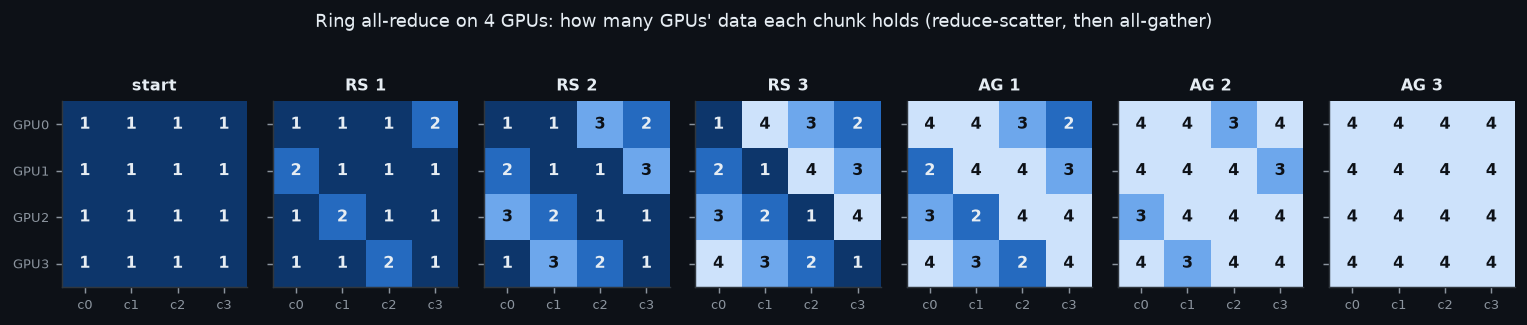

N=32: every GPU sent 63,488 bytes = 2(N-1)/N x 32,768  ✓  (ring result == library all-reduce ✓)


In [6]:
show_code(ring_all_reduce)


def ring_run(N, S_elems):
    cl = VirtualCluster(N)

    def fn(rank, gpu, comm):
        trace = []
        x = torch.randn(S_elems, generator=torch.Generator().manual_seed(rank))
        ring = ring_all_reduce(comm, x, trace)
        ref = x.clone()
        comm.all_reduce(ref, tag="ref", average=False)
        sent = comm.stats.bytes[("ring", "send")]
        return ring, ref, trace, sent

    return cl.run(fn)


r4 = ring_run(4, 4 * 8)
save_fig(zp.ring_heatmap({r: r4[r][2] for r in range(4)}, 4), "ring_allreduce.png")
r32 = ring_run(WORLD, WORLD * 256)
S_bytes = WORLD * 256 * 4
for rank, (ring, ref, trace, sent) in enumerate(r32):
    assert torch.allclose(ring, ref, rtol=1e-5, atol=1e-5)
    assert sent == 2 * (WORLD - 1) * S_bytes // WORLD
    assert all(c == WORLD for c in trace[-1][2])
print(f"N=32: every GPU sent {r32[0][3]:,} bytes = 2(N-1)/N x {S_bytes:,}  ✓  "
      f"(ring result == library all-reduce ✓)")
RESULTS["ring"] = {"N": WORLD, "S_bytes": S_bytes, "sent_per_gpu": r32[0][3],
                   "formula": 2 * (WORLD - 1) * S_bytes // WORLD}

**What you should see** (heatmap, N = 4): at the start every chunk holds 1 GPU's data.
After 3 reduce-scatter steps each GPU owns exactly one complete chunk (4 contributions) —
GPU r owns chunk (r+1) mod N in this ring's schedule; which chunk is only a convention.
After 3 all-gather steps every chunk on every GPU holds 4.

> **Takeaway.** All-reduce = reduce-scatter + all-gather, and each half costs
> (N−1)/N·S per GPU. ZeRO simply stops after the first half when it only needs a slice.

## 4 — The demo model, and how it is cut into units

**Why.** ZeRO shards at the granularity of **units** (FSDP calls them "wrapped
modules"): each unit's parameters are flattened into one buffer, padded, and split into
N equal slices. Our model is a nanoGPT-style decoder trained on tiny Shakespeare
(characters), with untied input/output embeddings and attention written as explicit
matmuls (so every FLOP is counted — PyTorch's fused CPU attention is invisible to the
FLOP counter).

```text
 block0 weights ──flatten──► [■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■·pad·]
                              │ GPU0 │ GPU1 │ GPU2 │  ...        │ GPU31 │
 data: global batch = 32 sequences ──► GPU r trains on sequence r
```

In [7]:
show_code(zero_sim.Block, zero_sim.Attention)
specs = make_units(cfg, WORLD)
PSI = sum(s.numel for s in specs)
P = sum(s.padded for s in specs)
print(f"{'unit':10s} {'params':>10s} {'padded to N*64':>15s} {'slice per GPU':>14s}")
for s in specs:
    print(f"{s.name:10s} {s.numel:>10,} {s.padded:>15,} {s.shard(WORLD):>14,}")
print(f"{'total':10s} {PSI:>10,} {P:>15,} {P // WORLD:>14,}   (padding +{(P - PSI) / PSI:.1%})")
specs3 = make_units(cfg, 3)
print(f"\nWith N = 3 (uneven): padded total {sum(s.padded for s in specs3):,}, "
      f"slice per GPU {sum(s.shard(3) for s in specs3):,}")
if not QUICK_RUN:
    assert PSI == 813_568 and P == 823_296
RESULTS["model"] = {"config": vars(cfg), "psi": PSI, "P": P, "world": WORLD,
                    "units": [dict(name=s.name, numel=s.numel, padded=s.padded,
                                   shard=s.shard(WORLD)) for s in specs]}

class Block(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = Attention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))

class Attention(nn.Module):
    """Causal self-attention written as explicit matmuls. (PyTorch's fused SDPA kernel on
    CPU is invisible to FlopCounterMode, so it would silently count as 0 FLOPs.)"""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.n_head = cfg.n_head
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=False)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        H = self.n_head
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (z.view(B, T, H, C // H).transpose(1, 2) for z in (q, k, v))
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(C // H))
        att = att.masked_fill(_causal_mask(T, x.device), float("-inf"))
        att = F.softmax(att.float(), dim=-1).to(x.dtype)
        y = (att @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(y)

unit           params  padded to N*64  slice per GPU
embed          16,512          18,432            576
block0        197,120         198,656          6,208
block1        197,120         198,656          6,208
block2        197,120         198,656          6,208
block3        197,120         198,656          6,208
head            8,576          10,240            320
total         813,568         823,296         25,728   (padding +1.2%)

With N = 3 (uneven): padded total 813,888, slice per GPU 271,296


**What you should see:** six units (embeddings, four blocks, head); every padded size is
a multiple of 32 × 64 = 2,048, so each GPU owns an equal, SIMD-aligned slice. Padding
costs about 1%.

> **Takeaway.** A shard is a *contiguous slice of a flat buffer*, not a set of whole
> tensors. That is what makes reduce-scatter and all-gather map one-to-one onto it.

## 5–8 — The four stages

**One executor runs them all.** Forward runs unit by unit; each unit's input is detached
so its backward can run on its own, in reverse. That leaves room to do work *between*
units. The stages differ only in what they do in five hooks:

```text
               ───────── forward ────────►   ◄──────── backward ─────────   ── optimizer step ──
DDP          [E][B0][B1][B2][B3][F]        [F][B3][B2][B1][B0][E]          Adam on all Ψ
                                            AR  AR  AR  AR  AR  AR
ZeRO-1       [E][B0][B1][B2][B3][F]        [F][B3][B2][B1][B0][E]  RS×6    Adam on Ψ/N ─► AG×6
ZeRO-2       [E][B0][B1][B2][B3][F]        [F][B3][B2][B1][B0][E]          Adam on Ψ/N ─► AG×6
                                            RS  RS  RS  RS  RS  RS   ← grad freed after its RS
ZeRO-3       AG  AG  AG  AG  AG  AG         AG  AG  AG  AG  AG  AG          Adam on Ψ/N
             [E][B0][B1][B2][B3][F]        [F][B3][B2][B1][B0][E]
              ↓ weights freed after use     RS  RS  RS  RS  RS  RS   ← weights + grads freed
AR = all-reduce   RS = reduce-scatter   AG = all-gather
```

Every stage trains **the same model on the same data for the same steps**. Each run
records, on every GPU: the ledger at the end of backward (the moment the ZeRO formulas
describe), the peak, the bytes sent, the FLOPs (step 1) and a full memory timeline
(step 2, GPU 0).

In [8]:
show_code(zero_sim.Engine._forward_backward)
runs = {}
RESULTS["stages"] = {}


def expected_comm(stage, P, N, bw=2):
    return (3 if stage == 3 else 2) * (N - 1) * bw * P // N


def run_stage(stage):
    rc = RunConfig(stage=stage, world=WORLD, steps=STEPS, seed=SEED, flops_step=0,
                   timeline_step=min(1, STEPS - 1))
    t0 = time.time()
    r = run_training(rc, cfg, data, init)
    r.wall = time.time() - t0
    runs[stage] = r
    last = r.records[-1]
    snap = last[0]["end_of_backward"]
    ms = sum(snap[c] for c in MODEL_STATES)
    formula = expected_model_state_bytes(stage, r.P, WORLD)
    comm = last[0]["comm"]
    same_everywhere = all(last[k]["end_of_backward"] == snap for k in range(WORLD))
    peak = max(r.records[s][0]["peak"] for s in range(STEPS))
    print(f"{STAGES[stage].label} — GPU 0 of {WORLD}, end of backward (step {STEPS}):")
    for c in MODEL_STATES:
        print(f"   {c:9s} {snap[c]:>12,} B  {mib(snap[c]):7.3f} MiB")
    print(f"   model states {ms:>9,} B = {mib(ms):.3f} MiB   formula {formula:,} B   "
          f"{'✓ exact' if ms == formula else '✗ MISMATCH'}")
    print(f"   identical on all {WORLD} GPUs: {same_everywhere}   peak (with activations "
          f"and temporaries): {mib(peak):.2f} MiB")
    print(f"   sent per step: {comm.total_bytes():,} B in {comm.total_calls()} collectives "
          f"{dict(comm.by_op())}   formula {expected_comm(stage, r.P, WORLD):,} B")
    print(f"   {STEPS} steps in {r.wall:.1f} s ({r.wall / STEPS:.2f} s/step on CPU threads); "
          f"activations left after backward: {last[0]['activations_left']} B")
    assert ms == formula and same_everywhere
    assert comm.total_bytes() == expected_comm(stage, r.P, WORLD)
    assert all(rec[k]["activations_left"] == 0 for rec in r.records for k in range(WORLD))
    RESULTS["stages"][str(stage)] = dict(
        label=STAGES[stage].label, model_state_bytes=ms, formula_bytes=formula,
        end_of_backward=snap, peak_bytes=peak, comm_bytes=comm.total_bytes(),
        comm_calls=comm.total_calls(), comm_by_op=dict(comm.by_op()),
        ring_steps=comm.total_ring_steps(), flops=r.flops[0], opt_elements=r.opt_elements[0],
        seconds_per_step=r.wall / STEPS, losses=r.losses)
    return r

def _forward_backward(self, x, y, G, first, last) -> float:
        acts = self.gpu.saved_tensor_hooks(self._booked_elsewhere)
        saved = []
        h = x
        for u in self.units:                                     # ---- forward
            self.gpu.phase = f"fwd:{u.name}"
            self.before_forward(u)
            x_in = h.detach().requires_grad_(True) if h.is_floating_point() else h
            if self.checkpoint and x_in.is_floating_point():    # the one tensor a checkpointed
                st = x_in.untyped_storage()                     # unit keeps: its input
                self.gpu.alloc(f"ckpt:{u.name}", st.nbytes(), "activations")
                self._ckpt_ptrs.add(st.data_ptr())
            grad_ctx = torch.no_grad() if self.checkpoint else nullcontext()
            with acts, grad_ctx, self._counting("forward"):
                out = self._run_unit(u, x_in, y, G)
            saved.append((x_in, out))
            self.after_forward(u)
            h = out
        loss_val = float(h.detach())
        self._probe("end_of_forward")
        if first:
            self.begin_backward()
        grad = None
        for k in reversed(range(len(self.units))):             # ---- backward
            u = self.units[k]
            x_in, out = saved[k]
            saved[k] = None
            self.gpu.phase = f"bwd:{u.name}"
            self.before_backward(u)
            if self.checkpoint:                                 # recompute the unit's forward
                with acts, self._counting("recompute"):
                    out = self._run_unit(u, x_in, y, G)
            with self._counting("backward"):
                torch.autograd.backward(out, grad)
            self._check_grads(u)
            grad = x_in.grad if x_in.is_floating_point() else None
            if self.checkpoint and x_in.is_floating_point():
                self._ckpt_ptrs.discard(x_in.untyped_storage().data_ptr())
                self.gpu.free(f"ckpt:{u.name}")
            del out, x_in
            self.after_backward(u, last)
        return loss_val

### 5 — DDP (ZeRO-0): everyone holds everything

Every GPU keeps all weights, all gradients and the whole optimizer. After each unit's
backward, its gradient is **all-reduced** (the same trick PyTorch DDP's gradient buckets
use to overlap communication with the rest of backward).

In [9]:
show_code(zero_sim.DDP)
run_stage(0);

class DDP(Engine):
    """ZeRO stage 0. Every GPU holds all weights, all gradients and the whole optimizer.
    Gradients are all-reduced unit by unit as backward produces them."""
    stage, label = 0, "DDP (ZeRO-0)"

    def setup(self):
        for u in self.units:
            self._new_full_weights(u)                        # 2Ψ weights
            self._new_optimizer(u, sharded=False)            # 12Ψ master + m + v

    def begin_backward(self):
        for u in self.units:
            self._new_full_grads(u, "grads")                 # 2Ψ grads

    def after_backward(self, u, last_micro):
        if last_micro:
            self.comm.all_reduce(u.flat_g, tag="grad_sync")  # 2Ψ of traffic in total

    def step(self, lr):
        for u in self.units:
            p32 = u.master if self.mixed else u.flat_w
            self._adamw(u, p32, u.flat_g, lr)                # Ψ elements updated per GPU
            if self.mixed:
                u.flat_w.copy_(u.master)
            self._drop_full_grads(u)

DDP (ZeRO-0) — GPU 0 of 32, end of backward (step 25):
   weights      1,646,592 B    1.570 MiB
   grads        1,646,592 B    1.570 MiB
   master       3,293,184 B    3.141 MiB
   adam_m       3,293,184 B    3.141 MiB
   adam_v       3,293,184 B    3.141 MiB
   model states 13,172,736 B = 12.562 MiB   formula 13,172,736 B   ✓ exact
   identical on all 32 GPUs: True   peak (with activations and temporaries): 14.04 MiB
   sent per step: 3,190,272 B in 6 collectives {'all_reduce': 3190272}   formula 3,190,272 B
   25 steps in 45.6 s (1.82 s/step on CPU threads); activations left after backward: 0 B


### 6 — ZeRO-1: shard the optimizer states

Weights and (during backward) gradients stay whole. After backward the gradients are
**reduce-scattered**: GPU r receives the averaged gradient for *its* slice only, updates
its slice of the fp32 master copy and Adam states, writes the result into its slice of the
bf16 weights, and an **all-gather** puts the updated weights back on every GPU.

In [10]:
show_code(zero_sim.ZeRO1)
run_stage(1);

class ZeRO1(Engine):
    """Stage 1: shard the optimizer states. Each GPU keeps all weights and (during
    backward) all gradients, but only 1/N of the fp32 master + Adam m, v. After backward,
    gradients are reduce-scattered (each GPU receives the slice it owns), the GPU updates
    its slice, and an all-gather puts the updated weights back on every GPU."""
    stage, label = 1, "ZeRO-1"

    def setup(self):
        for u in self.units:
            self._new_full_weights(u)                        # 2Ψ weights
            self._new_optimizer(u, sharded=True)             # 12Ψ/N

    def begin_backward(self):
        for u in self.units:
            self._new_full_grads(u, "grads")                 # 2Ψ grads (full, for now)

    def end_of_backward(self):
        for u in self.units:
            self._reduce_scatter_grads(u)                    # Ψ of traffic
            self._drop_full_grads(u)

    def step(self, lr):
        for u in self.units:
            my_w = u.flat_w[u.lo:u.hi]
            p32 = u.master if self.mixed else my_w
            self._adamw(u, p32, u.g_shard, lr)               # Ψ/N elements updated per GPU
            if self.mixed:
                my_w.copy_(u.master)
            u.g_shard = None
            self.gpu.free(f"g_shard:{u.name}")
            self.comm.all_gather(my_w, u.flat_w, tag="param_gather")   # Ψ of traffic

ZeRO-1 — GPU 0 of 32, end of backward (step 25):
   weights      1,646,592 B    1.570 MiB
   grads        1,646,592 B    1.570 MiB
   master         102,912 B    0.098 MiB
   adam_m         102,912 B    0.098 MiB
   adam_v         102,912 B    0.098 MiB
   model states 3,601,920 B = 3.435 MiB   formula 3,601,920 B   ✓ exact
   identical on all 32 GPUs: True   peak (with activations and temporaries): 4.86 MiB
   sent per step: 3,190,272 B in 12 collectives {'reduce_scatter': 1595136, 'all_gather': 1595136}   formula 3,190,272 B
   25 steps in 41.1 s (1.64 s/step on CPU threads); activations left after backward: 0 B


### 7 — ZeRO-2: also shard the gradients

Same as ZeRO-1, but the reduce-scatter happens **as soon as each unit's backward
finishes**, and the full-size gradient buffer is freed immediately. A GPU never holds more
than one unit's full gradient.

In [11]:
show_code(zero_sim.ZeRO2)
run_stage(2);

class ZeRO2(ZeRO1):
    """Stage 2: also shard the gradients. As soon as a unit's backward finishes, its
    gradient is reduce-scattered and the full-size buffer is freed, so a GPU never holds
    more than one unit's full gradient at a time."""
    stage, label = 2, "ZeRO-2"

    def begin_backward(self):
        pass                                                 # no full-size gradients up front

    def before_backward(self, u):
        self._new_full_grads(u, "temp")                      # one unit, briefly

    def after_backward(self, u, last_micro):
        self._reduce_scatter_grads(u)                        # every micro-batch
        self._drop_full_grads(u)

    def end_of_backward(self):
        pass

ZeRO-2 — GPU 0 of 32, end of backward (step 25):
   weights      1,646,592 B    1.570 MiB
   grads           51,456 B    0.049 MiB
   master         102,912 B    0.098 MiB
   adam_m         102,912 B    0.098 MiB
   adam_v         102,912 B    0.098 MiB
   model states 2,006,784 B = 1.914 MiB   formula 2,006,784 B   ✓ exact
   identical on all 32 GPUs: True   peak (with activations and temporaries): 3.63 MiB
   sent per step: 3,190,272 B in 12 collectives {'reduce_scatter': 1595136, 'all_gather': 1595136}   formula 3,190,272 B
   25 steps in 40.0 s (1.60 s/step on CPU threads); activations left after backward: 0 B


### 8 — ZeRO-3: also shard the weights

A unit's full weights exist only while it runs: **all-gathered** just before its
forward, **freed** right after, gathered **again** for its backward. Freeing means
shrinking the buffer's storage to 0 bytes (`untyped_storage().resize_(0)`) — the trick
PyTorch FSDP uses. The module's parameters are views into that storage, and so are the
tensors autograd saved; when the storage is regrown and refilled before backward, they
all see the right numbers again. (Reading a freed weight would crash the process rather
than raise, so a forward pre-hook guards every unit.)

In [12]:
show_code(zero_sim.ZeRO3)
run_stage(3);

class ZeRO3(Engine):
    """Stage 3: also shard the weights. A unit's full weights exist only while it runs:
    all-gathered just before its forward, freed right after, and gathered again for its
    backward. Freeing means shrinking the storage to 0 bytes; autograd's saved references
    point at that same storage, so re-gathering brings them back to life."""
    stage, label = 3, "ZeRO-3"

    def setup(self):
        for u in self.units:
            self._new_full_weights(u, category="temp")       # bind param views, then...
            u.w_shard = self.gpu.tensor(f"w_shard:{u.name}", u.hi - u.lo, self.w_dtype, "weights")
            u.w_shard.copy_(u.flat_w[u.lo:u.hi])             # 2Ψ/N weights
            self._release(u)                                 # ...drop the full copy
            self._new_optimizer(u, sharded=True)             # 12Ψ/N

    def _gather(self, u):
        self.gpu.alloc(f"w:{u.name}", u.flat_w.dtype.itemsize * u.spec.padded, "temp")
        u.flat_w.untyped_storage().resize_(u.flat_w.dtype.itemsize * u.spec.padded)
        self.comm.all_gather(u.w_shard, u.flat_w, tag="param_gather")

    def _release(self, u):
        u.flat_w.untyped_storage().resize_(0)
        self.gpu.free(f"w:{u.name}")

    def before_forward(self, u):
        self._gather(u)                                      # Ψ of traffic over the forward

    def after_forward(self, u):
        self._release(u)

    def before_backward(self, u):
        self._gather(u)                                      # Ψ again over the backward
        self._new_full_grads(u, "temp")

    def after_backward(self, u, last_micro):
        self._reduce_scatter_grads(u)                        # Ψ: the third one
        self._drop_full_grads(u)
        self._release(u)

    def step(self, lr):
        for u in self.units:
            p32 = u.master if self.mixed else u.w_shard
            self._adamw(u, p32, u.g_shard, lr)
            if self.mixed:
                u.w_shard.copy_(u.master)                    # weights stay sharded
            u.g_shard = None
            self.gpu.free(f"g_shard:{u.name}")

ZeRO-3 — GPU 0 of 32, end of backward (step 25):
   weights         51,456 B    0.049 MiB
   grads           51,456 B    0.049 MiB
   master         102,912 B    0.098 MiB
   adam_m         102,912 B    0.098 MiB
   adam_v         102,912 B    0.098 MiB
   model states   411,648 B = 0.393 MiB   formula 411,648 B   ✓ exact
   identical on all 32 GPUs: True   peak (with activations and temporaries): 2.48 MiB
   sent per step: 4,785,408 B in 18 collectives {'all_gather': 3190272, 'reduce_scatter': 1595136}   formula 4,785,408 B
   25 steps in 40.9 s (1.64 s/step on CPU threads); activations left after backward: 0 B


**What you should see across 5–8:** model-state bytes that match the formula **to the
byte** on every GPU; the same bytes sent by DDP, ZeRO-1 and ZeRO-2, and 1.5× that for
ZeRO-3; 6 → 12 → 12 → 18 collective calls; zero activation bytes left after backward.

> **Takeaway.** Each stage is a small diff of hooks on the same executor: *when* you
> reduce, *what* you keep, and *whether* you gather.

## 9 — Correctness: ZeRO changes memory, not maths

**Why.** A memory optimization that changes the answer is not an optimization. Every
stage sums gradients through the same code (rank order, fp32, divide by N), the optimizer
is elementwise (a slice update equals the full update), and shard boundaries are aligned.
So with one micro-batch per step (as here) the claim is not "close" — it is
**bit-identical**. (With gradient accumulation the stages add in different orders; §13
measures that.)

In [13]:
for s in (1, 2, 3):
    assert runs[s].losses == runs[0].losses, f"stage {s} losses differ"
    c0, cs = runs[0].consolidated(), runs[s].consolidated()
    assert all(torch.equal(c0[k], cs[k]) for k in c0), f"stage {s} weights differ"
print(f"{'step':>4s} " + " ".join(f"{STAGES[s].label:>14s}" for s in range(4)))
for i in range(STEPS):
    print(f"{i + 1:>4d} " + " ".join(f"{runs[s].losses[i]:>14.6f}" for s in range(4)))
print("\nlosses bit-identical across all four stages ✓   final weights bit-identical ✓")
RESULTS["equivalence"] = {"steps": STEPS, "bit_identical_losses": True,
                          "bit_identical_weights": True,
                          "losses": {s: runs[s].losses for s in range(4)}}

step   DDP (ZeRO-0)         ZeRO-1         ZeRO-2         ZeRO-3
   1       4.177242       4.177242       4.177242       4.177242
   2       3.791558       3.791558       3.791558       3.791558
   3       3.654794       3.654794       3.654794       3.654794
   4       3.540212       3.540212       3.540212       3.540212
   5       3.753567       3.753567       3.753567       3.753567
   6       3.453734       3.453734       3.453734       3.453734
   7       3.387454       3.387454       3.387454       3.387454
   8       3.282402       3.282402       3.282402       3.282402
   9       3.254971       3.254971       3.254971       3.254971
  10       3.278960       3.278960       3.278960       3.278960
  11       3.119900       3.119900       3.119900       3.119900
  12       3.139391       3.139391       3.139391       3.139391
  13       3.063833       3.063833       3.063833       3.063833
  14       3.049474       3.049474       3.049474       3.049474
  15       3.105047      

**And DDP on 32 GPUs equals one big GPU.** In fp32, 32 GPUs × 1 sequence each must match
1 GPU × 32 sequences, up to the order of floating-point summation.

In [14]:
r32 = run_training(RunConfig(stage=0, world=WORLD, steps=FP32_STEPS, precision="fp32"), cfg,
                   data, init)
r1 = run_training(RunConfig(stage=0, world=1, micro_bsz=WORLD, steps=FP32_STEPS,
                            precision="fp32"), cfg, data, init)
dl = max(abs(a - b) for a, b in zip(r32.losses, r1.losses))
w32, w1 = r32.module_flats(cfg), r1.module_flats(cfg)
dw = max((w32[k] - w1[k]).abs().max().item() for k in w32)
print(f"fp32, {FP32_STEPS} steps: max |loss diff| = {dl:.2e}, max |weight diff| = {dw:.2e}")
# Tight on purpose: Adam is nearly scale-invariant, so forgetting to divide the summed
# gradient by N (the classic DDP bug) moves the weights by only ~1e-4 — these tolerances
# catch it (tests/test_zero_sim.py::test_missing_average_is_caught proves that).
assert dl < 5e-6 and dw < 2e-5
RESULTS["equivalence"]["ddp_vs_single_gpu"] = {"steps": FP32_STEPS, "max_loss_diff": dl,
                                               "max_weight_diff": dw}

fp32, 5 steps: max |loss diff| = 7.15e-07, max |weight diff| = 1.56e-06


**What you should see:** four identical loss columns and exact weight equality; DDP vs a
single device agreeing to ~1e-6 (not exactly: 32 means-of-64 vs one mean-of-2048 round
differently), well inside tolerances that a missing ÷N would break.

> **Takeaway.** ZeRO is a *layout* change. Given the same reduction order, it computes
> the same training run, bit for bit.

## 10 — Memory: measured vs formula, on every GPU

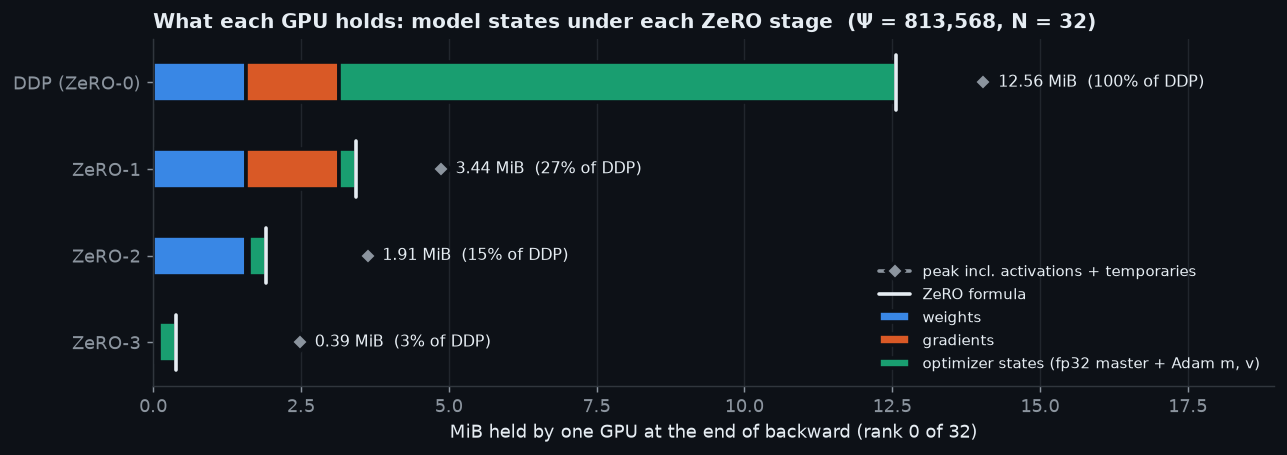

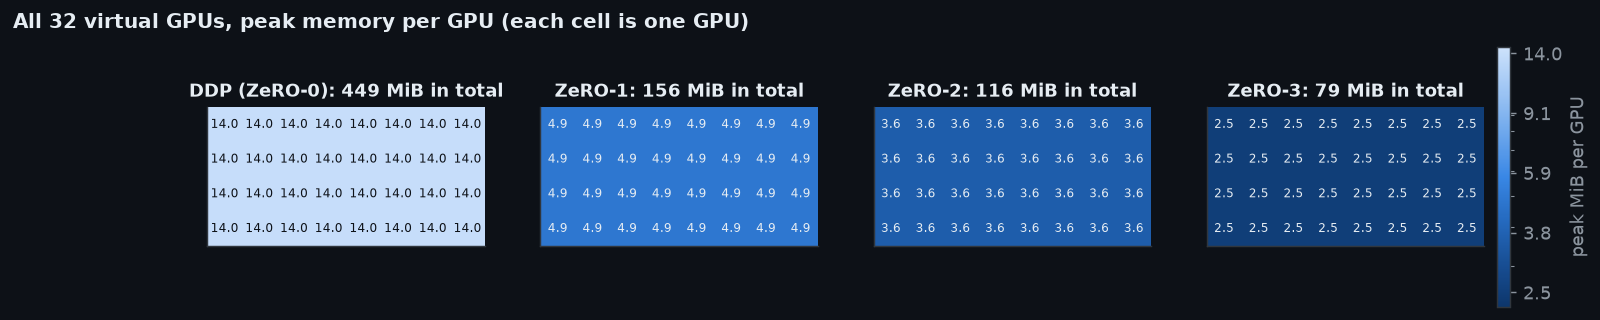

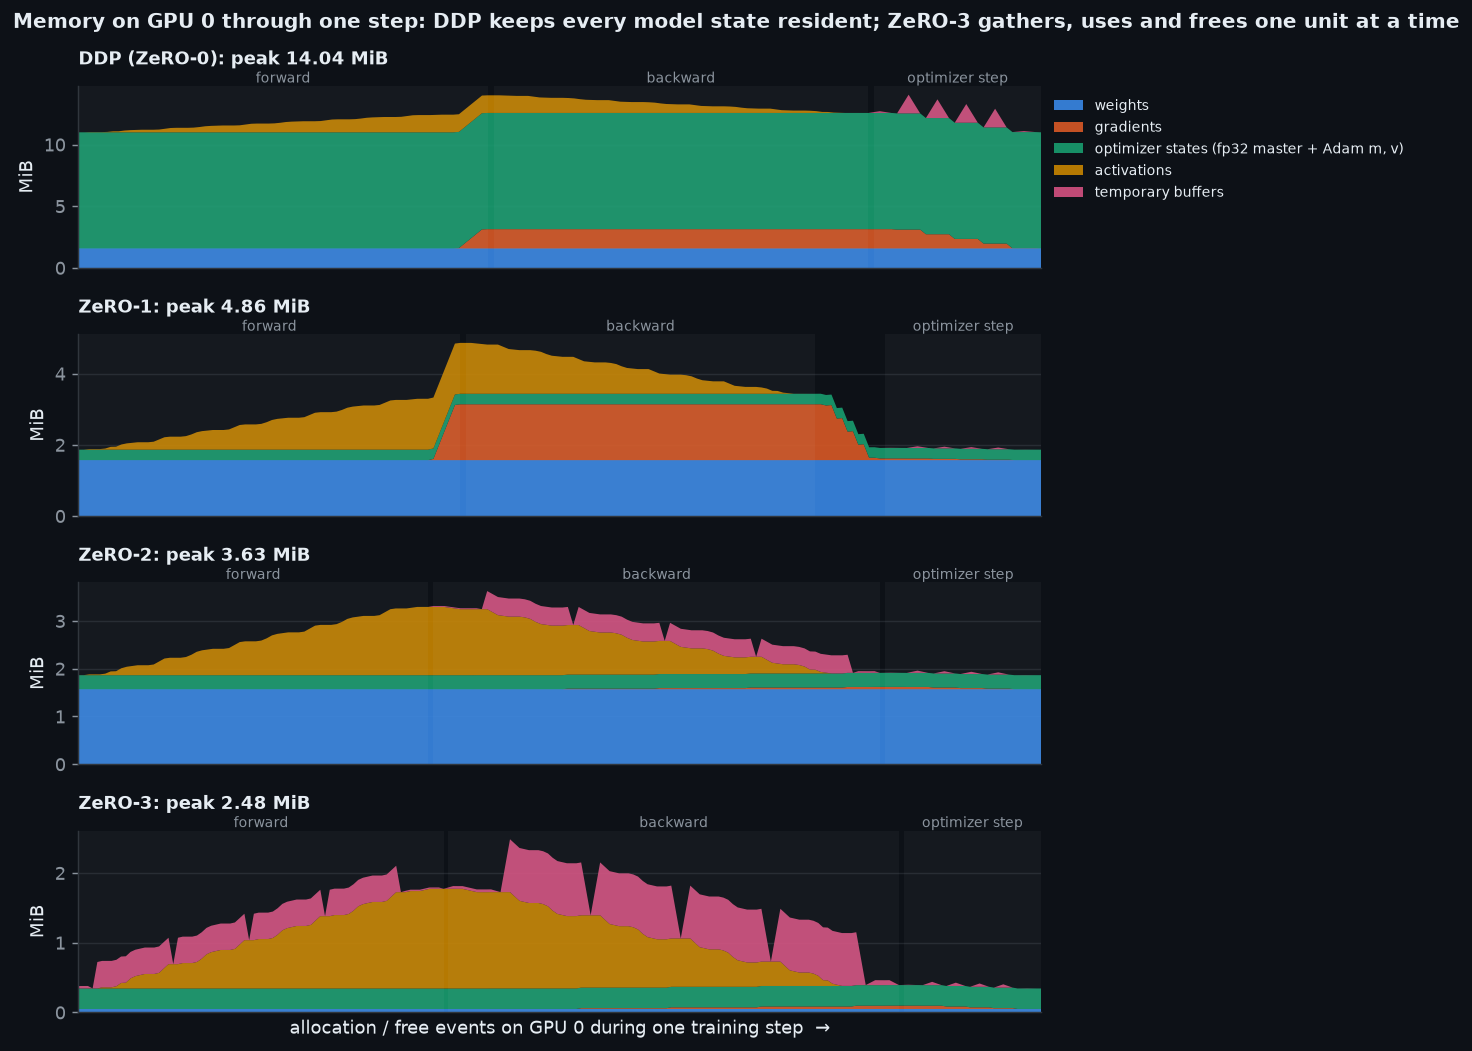

stage            model states  x smaller   peak/GPU  all 32 GPUs
DDP (ZeRO-0)       12.562 MiB       1.0x   14.04 MiB    449.4 MiB
ZeRO-1              3.435 MiB       3.7x    4.86 MiB    155.7 MiB
ZeRO-2              1.914 MiB       6.6x    3.63 MiB    116.0 MiB
ZeRO-3              0.393 MiB      32.0x    2.48 MiB     79.5 MiB


In [15]:
stage_view = {s: dict(snapshot=runs[s].records[-1][0]["end_of_backward"],
                      formula=expected_model_state_bytes(s, P, WORLD),
                      peak=RESULTS["stages"][str(s)]["peak_bytes"]) for s in range(4)}
save_fig(zp.what_each_gpu_holds(stage_view, f"Ψ = {PSI:,}, N = {WORLD}"), "what_each_gpu_holds.png")
peaks = {s: [max(rec[k]["peak"] for rec in runs[s].records) for k in range(WORLD)]
         for s in range(4)}
save_fig(zp.cluster_heatmap(peaks, WORLD), "cluster_heatmap.png")
save_fig(zp.memory_timeline({s: runs[s].timelines[0] for s in range(4)}), "memory_timeline.png")
print(f"{'stage':14s} {'model states':>14s} {'x smaller':>10s} {'peak/GPU':>10s} {'all 32 GPUs':>12s}")
for s in range(4):
    ms = RESULTS["stages"][str(s)]["model_state_bytes"]
    print(f"{STAGES[s].label:14s} {mib(ms):>10.3f} MiB {RESULTS['stages']['0']['model_state_bytes'] / ms:>9.1f}x "
          f"{mib(max(peaks[s])):>7.2f} MiB {mib(sum(peaks[s])):>8.1f} MiB")

**Wrap granularity.** ZeRO-3 only ever materializes *one unit at a time*, so the unit
size sets the floor of its peak. Wrap the whole model as a single unit and ZeRO-3 must
gather everything at once:

In [16]:
whole = run_training(RunConfig(stage=3, world=WORLD, steps=1, wrap="whole", keep_state=False),
                     cfg, data, init)
wp, bp = whole.records[0][0]["peak"], runs[3].records[0][0]["peak"]
wt, bt = whole.records[0][0]["cat_peak"]["temp"], runs[3].records[0][0]["cat_peak"]["temp"]
print(f"ZeRO-3, one unit per block : peak {mib(bp):.2f} MiB (largest temporary {mib(bt):.2f} MiB)")
print(f"ZeRO-3, whole model 1 unit : peak {mib(wp):.2f} MiB (largest temporary {mib(wt):.2f} MiB)")
assert wp > bp
RESULTS["wrap"] = {"per_block_peak": bp, "whole_model_peak": wp, "per_block_temp": bt,
                   "whole_model_temp": wt}

ZeRO-3, one unit per block : peak 2.48 MiB (largest temporary 0.76 MiB)
ZeRO-3, whole model 1 unit : peak 4.88 MiB (largest temporary 3.11 MiB)


**What you should see:**
* Bars that shrink stage by stage and land on the formula ticks. Model states:
  DDP 16Ψ → ZeRO-1 ≈ 4.4Ψ → ZeRO-2 ≈ 2.4Ψ → ZeRO-3 0.5Ψ at N = 32 (32× smaller).
* All 32 GPUs shrink together (the heatmap is uniform within a stage — ZeRO is symmetric).
* On the timeline, DDP is a flat plateau; ZeRO-3 is a sawtooth of *gather → use → free*.
* At this toy size ZeRO-3's **peak** is dominated by activations and one gathered unit,
  not by model states — which is exactly why real systems wrap per block and use
  activation checkpointing.

> **Takeaway.** Model states follow the formula exactly; the *peak* also depends on
> activations and on how big one gathered unit is.

## 11 — Computation and communication: what changes, what does not

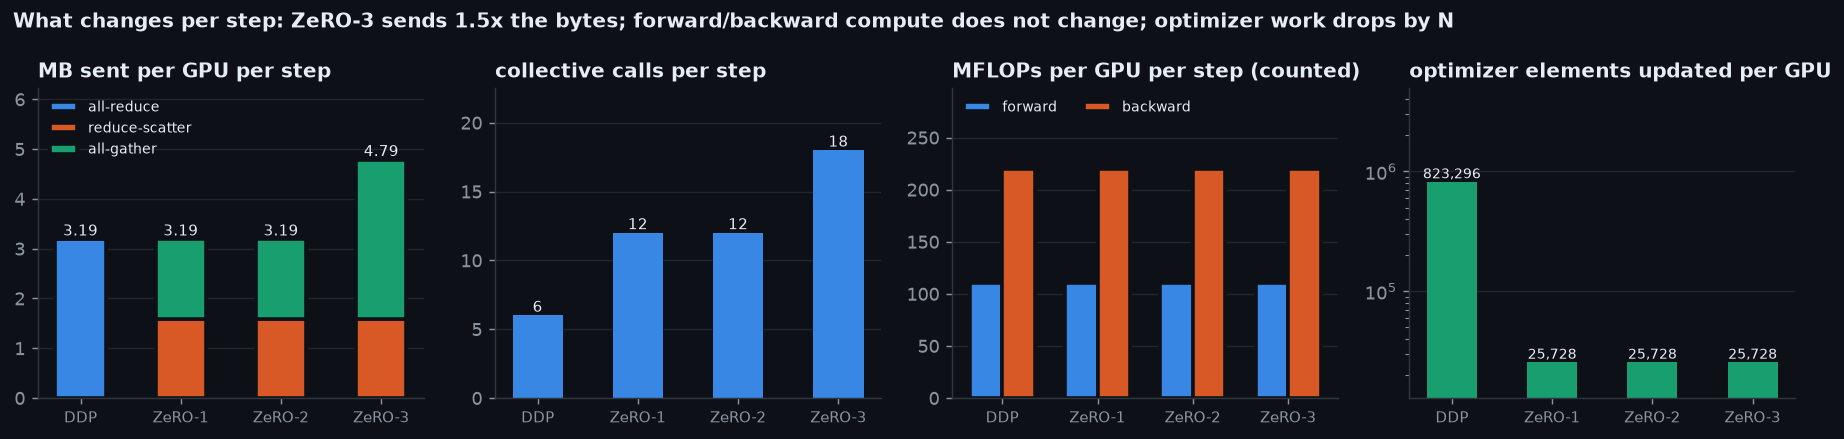

stage           fwd MFLOP  bwd MFLOP  opt elems  MB sent  calls ring steps
DDP (ZeRO-0)       110.12     220.23    823,296    3.190      6        372
ZeRO-1             110.12     220.23     25,728    3.190     12        372
ZeRO-2             110.12     220.23     25,728    3.190     12        372
ZeRO-3             110.12     220.23     25,728    4.785     18        558

forward FLOPs = 2·tokens·(12·L·d² + d·V) + 4·L·T²·d = 110,116,864 (counted = formula ✓); backward = 2 × forward ✓

footnote — wall-clock on CPU threads (not a GPU proxy), seconds per step on GPU 0:
  DDP (ZeRO-0)   forward 0.432  backward 0.578  step 0.245  in collectives 0.507
  ZeRO-1         forward 0.477  backward 0.572  step 0.209  in collectives 0.474
  ZeRO-2         forward 0.418  backward 0.549  step 0.198  in collectives 0.504
  ZeRO-3         forward 0.381  backward 0.537  step 0.046  in collectives 0.590


In [17]:
summary = {}
for s in range(4):
    st = RESULTS["stages"][str(s)]
    summary[s] = dict(bytes_by_op=st["comm_by_op"], calls=st["comm_calls"],
                      flops_fwd=st["flops"].get("forward", 0),
                      flops_bwd=st["flops"].get("backward", 0), opt_elements=st["opt_elements"])
save_fig(zp.comm_and_compute(summary), "comm_and_compute.png")

B, T, d, L, V = 1, cfg.block_size, cfg.n_embd, cfg.n_layer, cfg.vocab_size
fwd_expected = 2 * B * T * (12 * L * d * d + d * V) + 4 * L * B * T * T * d
U = len(specs)
print(f"{'stage':14s} {'fwd MFLOP':>10s} {'bwd MFLOP':>10s} {'opt elems':>10s} "
      f"{'MB sent':>8s} {'calls':>6s} {'ring steps':>10s}")
for s in range(4):
    x, st = summary[s], RESULTS["stages"][str(s)]
    print(f"{STAGES[s].label:14s} {x['flops_fwd'] / 1e6:>10.2f} {x['flops_bwd'] / 1e6:>10.2f} "
          f"{x['opt_elements']:>10,} {st['comm_bytes'] / 1e6:>8.3f} {x['calls']:>6d} "
          f"{st['ring_steps']:>10d}")
    assert x["flops_fwd"] == fwd_expected and x["flops_bwd"] == 2 * fwd_expected
    assert x["opt_elements"] == (P if s == 0 else P // WORLD)
    assert x["calls"] == {0: U, 1: 2 * U, 2: 2 * U, 3: 3 * U}[s]
print(f"\nforward FLOPs = 2·tokens·(12·L·d² + d·V) + 4·L·T²·d = {fwd_expected:,} "
      f"(counted = formula ✓); backward = 2 × forward ✓")
sec = {s: runs[s].seconds[0] for s in range(4)}
print("\nfootnote — wall-clock on CPU threads (not a GPU proxy), seconds per step on GPU 0:")
for s in range(4):
    print(f"  {STAGES[s].label:14s} " + "  ".join(
        f"{k} {v / STEPS:.3f}" for k, v in sec[s].items()) +
        f"  in collectives {runs[s].comm_seconds[0] / STEPS:.3f}")
RESULTS["compute"] = {"fwd_flops_formula": fwd_expected, "summary": summary}

**What you should see:**
* **Forward/backward FLOPs are identical** in all four stages, and equal to the closed
  form (backward = 2 × forward). ZeRO never changes the model's arithmetic.
* **Optimizer work** per GPU drops from Ψ′ to Ψ′/N: each GPU updates only its slice.
* **Bytes sent**: 2Ψ for DDP, ZeRO-1, ZeRO-2; 3Ψ for ZeRO-3 (it gathers weights twice
  — once for forward, once for backward — plus one reduce-scatter).
* **Calls**: ZeRO-3 issues 3 collectives per unit per step, each smaller; on real
  hardware each carries a latency cost, which is why DeepSpeed and FSDP prefetch the
  next unit's gather while the current one computes.

> **Takeaway.** ZeRO trades memory for communication, not for compute: 0% more
> FLOPs, 0% more bytes for stages 1–2, +50% bytes for stage 3.

## 12 — Scaling out: what happens as N grows

**Why.** The formulas say ZeRO-1 and ZeRO-2 approach a floor (4Ψ and 2Ψ: weights and
gradients that are never sharded), while ZeRO-3 keeps falling as 1/N. Measure it.

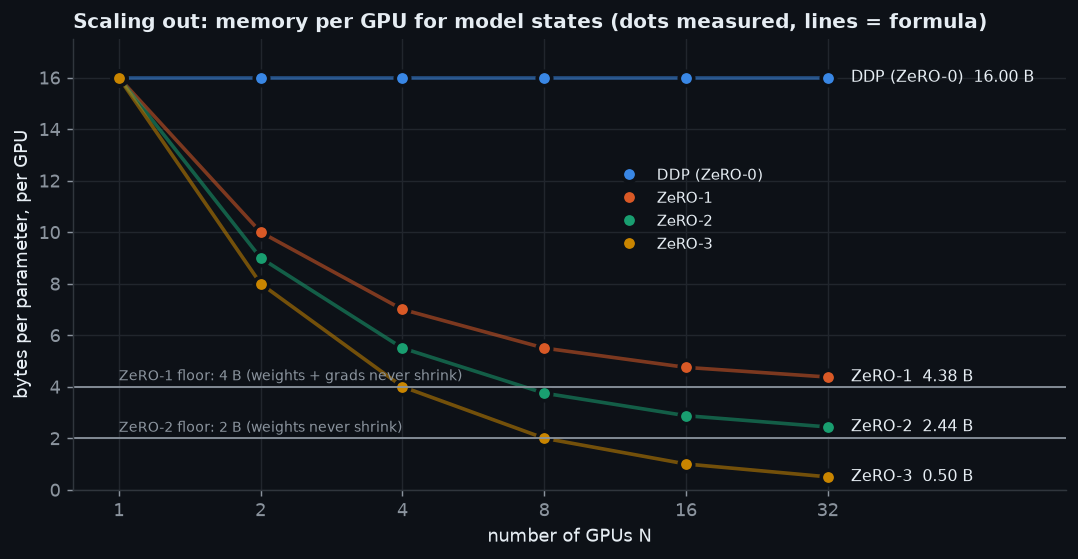

bytes per parameter per GPU:
   N     DDP (ZeRO-0)         ZeRO-1         ZeRO-2         ZeRO-3
   1           16.000         16.000         16.000         16.000
   2           16.000         10.000          9.000          8.000
   4           16.000          7.000          5.500          4.000
   8           16.000          5.500          3.750          2.000
  16           16.000          4.750          2.875          1.000
  32           16.000          4.375          2.438          0.500


In [18]:
scal = {s: [] for s in range(4)}
form = {s: [] for s in range(4)}
RESULTS["scaling"] = {}
for N in SCALING_NS:
    for s in range(4):
        r = run_training(RunConfig(stage=s, world=N, steps=1, keep_state=False), cfg, data, init)
        snap = r.records[0][0]["end_of_backward"]
        ms = sum(snap[c] for c in MODEL_STATES)
        assert ms == expected_model_state_bytes(s, r.P, N)
        scal[s].append(ms / r.P)
        form[s].append(expected_model_state_bytes(s, r.P, N) / r.P)
        RESULTS["scaling"][f"{N}/{s}"] = {"model_state_bytes": ms, "P": r.P,
                                          "peak": r.records[0][0]["peak"]}
save_fig(zp.scaling(SCALING_NS, scal, form), "scaling_with_N.png")
print("bytes per parameter per GPU:")
print("   N  " + "".join(f"{STAGES[s].label:>15s}" for s in range(4)))
for i, N in enumerate(SCALING_NS):
    print(f"{N:>4d}  " + "".join(f"{scal[s][i]:>15.3f}" for s in range(4)))

**What you should see:** at N = 1 every stage is 16 bytes/param (sharding across one GPU
is no sharding). DDP stays flat at 16; ZeRO-1 bends toward 4, ZeRO-2 toward 2; ZeRO-3
halves every time N doubles.

> **Takeaway.** Only ZeRO-3 turns "more GPUs" into "bigger model" without limit; ZeRO-1/2
> hit the floor of the replicated weights (and gradients).

## 13 — Two interactions every practitioner hits

**Gradient accumulation.** With G micro-batches per optimizer step, DDP and ZeRO-1 keep
full gradients and accumulate locally, so they communicate **once per step**. ZeRO-2 has
no full gradient buffer to accumulate into — it must reduce-scatter **every
micro-batch** — and ZeRO-3 must also re-gather weights every micro-batch. (This is also
why ZeRO-2/3 combine poorly with pipeline parallelism, which relies on many
micro-batches.)

In [19]:
G = 4
accum = {"G": G}
acc_runs = {}
for s in range(4):
    r = run_training(RunConfig(stage=s, world=WORLD, steps=2, grad_accum=G), cfg, data, init)
    acc_runs[s] = r
    many = r.records[0][0]["comm"].total_bytes()
    one = RESULTS["stages"][str(s)]["comm_bytes"]
    unit = (WORLD - 1) * 2 * P // WORLD                  # one Ψ of ring traffic, in bytes
    expected = {0: 2 * unit, 1: 2 * unit, 2: G * unit + unit, 3: 3 * G * unit}[s]
    assert many == expected, (s, many, expected)
    accum[s] = (one, many)
    print(f"{STAGES[s].label:14s} G=1: {one / 1e6:6.2f} MB   G={G}: {many / 1e6:6.2f} MB   "
          f"({many / one:.1f}x)")
RESULTS["grad_accum"] = {str(k): v for k, v in accum.items()}
c0 = acc_runs[0].consolidated()
diffs = {}
for s in (1, 2, 3):
    cs = acc_runs[s].consolidated()
    diffs[s] = dict(max_weight_diff=max((c0[k] - cs[k]).abs().max().item() for k in c0),
                    max_loss_diff=max(abs(a - b) for a, b in zip(acc_runs[s].losses,
                                                                 acc_runs[0].losses)))
print(f"\nafter 2 steps with G={G}, versus DDP:")
for s, d in diffs.items():
    print(f"  {STAGES[s].label:8s} max |weight diff| {d['max_weight_diff']:.2e}   "
          f"max |loss diff| {d['max_loss_diff']:.2e}")
assert diffs[1]["max_weight_diff"] == 0            # ZeRO-1 accumulates exactly like DDP
RESULTS["grad_accum_diffs"] = diffs

DDP (ZeRO-0)   G=1:   3.19 MB   G=4:   3.19 MB   (1.0x)


ZeRO-1         G=1:   3.19 MB   G=4:   3.19 MB   (1.0x)


ZeRO-2         G=1:   3.19 MB   G=4:   7.98 MB   (2.5x)


ZeRO-3         G=1:   4.79 MB   G=4:  19.14 MB   (4.0x)

after 2 steps with G=4, versus DDP:
  ZeRO-1   max |weight diff| 0.00e+00   max |loss diff| 0.00e+00
  ZeRO-2   max |weight diff| 2.01e-03   max |loss diff| 3.39e-05
  ZeRO-3   max |weight diff| 2.01e-03   max |loss diff| 3.39e-05


Why ZeRO-2/3 are no longer *bit*-identical here: DDP and ZeRO-1 add the G micro-batch
gradients locally (in bf16) and then sum across GPUs once; ZeRO-2/3 sum across GPUs every
micro-batch and then add the G reduced slices. Same maths, different order of
floating-point additions — so the last bits differ, while ZeRO-1 still matches DDP exactly.

**Activation checkpointing.** ZeRO shards model states, never activations. Checkpointing
keeps only each unit's input during forward and recomputes the unit during backward:
activations shrink, and compute grows from 6ΨD to about 8ΨD (one extra forward). It
composes with every stage — shown here on ZeRO-3.

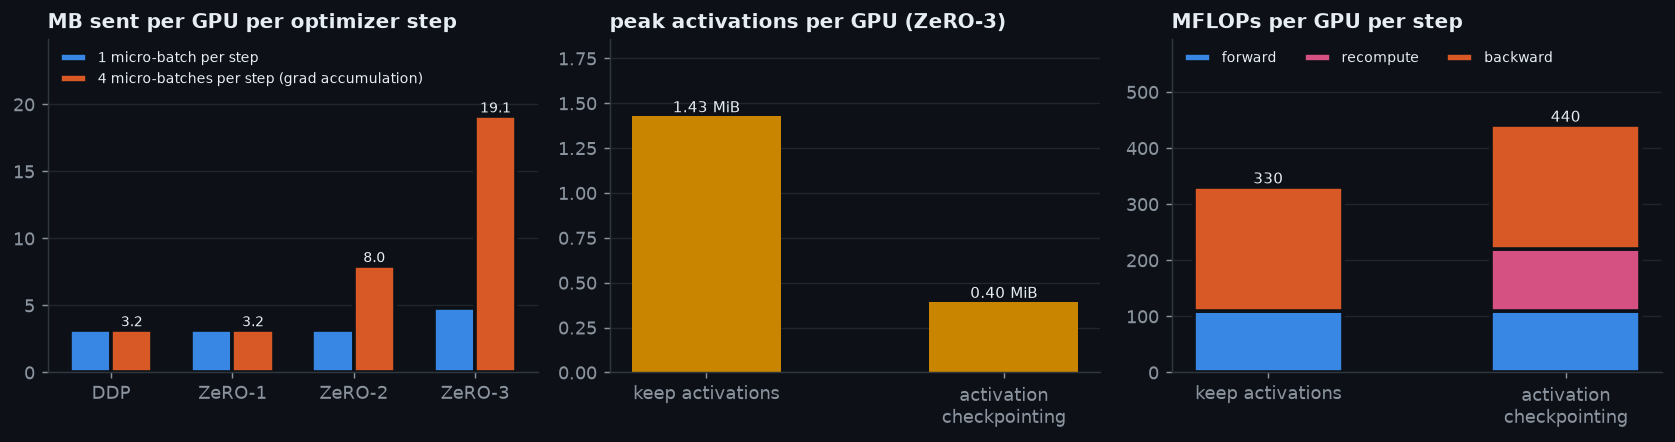

checkpointing no : peak activations 1.430 MiB, peak 2.48 MiB, fwd+bwd(+recompute) 330.4 MFLOP
checkpointing yes: peak activations 0.395 MiB, peak 1.50 MiB, fwd+bwd(+recompute) 440.5 MFLOP


In [20]:
ck, ck_runs = {}, {}
for flag in (False, True):
    r = run_training(RunConfig(stage=3, world=WORLD, steps=2, checkpoint=flag, flops_step=0),
                     cfg, data, init)
    ck_runs[flag] = r
    ck["yes" if flag else "no"] = dict(
        act=max(rec[0]["cat_peak"]["activations"] for rec in r.records), flops=r.flops[0],
        losses=r.losses, peak=max(rec[0]["peak"] for rec in r.records))
ca, cb = ck_runs[False].consolidated(), ck_runs[True].consolidated()
weights_equal = all(torch.equal(ca[k], cb[k]) for k in ca)
assert ck["yes"]["losses"] == ck["no"]["losses"] and weights_equal
assert ck["yes"]["flops"]["recompute"] == ck["yes"]["flops"]["forward"]
ck["steps"], ck["weights_equal"] = 2, weights_equal
save_fig(zp.grad_accum_and_ckpt(accum, ck), "grad_accum_and_ckpt.png")
for k in ("no", "yes"):
    tot = sum(ck[k]["flops"].get(p, 0) for p in ("forward", "recompute", "backward"))
    print(f"checkpointing {k:3s}: peak activations {mib(ck[k]['act']):.3f} MiB, "
          f"peak {mib(ck[k]['peak']):.2f} MiB, fwd+bwd(+recompute) {tot / 1e6:.1f} MFLOP")
RESULTS["checkpointing"] = ck

**What you should see:** ZeRO-2's traffic grows with G, ZeRO-3's grows 4×, DDP and
ZeRO-1 stay put. With checkpointing, peak activations fall (the ledger books each unit's
kept input), FLOPs rise by exactly one forward (8/6 = 1.33×), and after two steps the
losses and the weights are bit-identical to the run without it.

> **Takeaway.** Pick the stage *with* your micro-batching in mind, and remember that
> activations are a separate problem with a separate tool.

## 14 — When to use which stage

(Activations below use the same model as §19: Korthikanti et al., micro-batch 1 at each
model's context length, selective recomputation.)

```text
              Does 16Ψ + activations fit on one GPU?
                 │ yes                     │ no
                 ▼                         ▼
           DDP (ZeRO-0)          Does 4Ψ + 12Ψ/N fit? ──yes──► ZeRO-1
           least communication             │ no
                                           ▼
                                 Does 2Ψ + 14Ψ/N fit? ──yes──► ZeRO-2  (mind grad-accum comm)
                                           │ no
                                           ▼
                                 ZeRO-3 / FSDP FULL_SHARD   (1.5× communication)
                                           │ still no?
                                           ▼
                activation checkpointing ─► offload (ZeRO-Offload / Infinity)
                                         ─► tensor / pipeline parallelism
```

In [21]:
show_code(zt.decision)
RESULTS["decision"] = {}
for name, m in zt.MODELS.items():
    act = zt.activation_bytes_model(name, micro_bsz=1, recompute="selective")
    choice = zt.decision(m["n_params"], WORLD, 80e9, act)
    RESULTS["decision"][name] = choice
    print(f"{name:>12s} on 32 × 80 GB (activations {act / 1e9:5.1f} GB, micro-batch 1, "
          f"selective recompute): {choice}")

def decision(psi, n, gpu_mem_bytes, act_bytes, bytes_w=2, bytes_g=2, k_opt=12) -> str:
    """The plan's decision flowchart: pick the LEAST sharded stage that fits, because each
    step down the list costs something (ZeRO-2 communicates every micro-batch under
    accumulation; ZeRO-3 sends 1.5x the bytes).

        16Ψ + act fits on one GPU?        -> DDP (least communication)
        4Ψ + 12Ψ/N + act fits?            -> ZeRO-1 (same communication as DDP)
        2Ψ + 14Ψ/N + act fits?            -> ZeRO-2
        16Ψ/N + act fits?                 -> ZeRO-3 / FSDP FULL_SHARD
        otherwise                         -> ZeRO-3 plus activation checkpointing, then
                                             offload (ZeRO-Offload/Infinity), then tensor
                                             or pipeline parallelism

    act_bytes is whatever activations you plan to keep (already reduced by checkpointing
    if you use it). ZeRO never shards them.
    """
    for stage in STAGES:
        if model_state_bytes(stage, psi, n, bytes_w, bytes_g, k_opt) + act_bytes <= gpu_mem_bytes:
            return DECISIONS[stage]
    return DECISIONS[-1]

    GPT-2 XL on 32 × 80 GB (activations   2.7 GB, micro-batch 1, selective recompute): DDP
  LLaMA-2 7B on 32 × 80 GB (activations  18.3 GB, micro-batch 1, selective recompute): ZeRO-1
 LLaMA-2 13B on 32 × 80 GB (activations  28.5 GB, micro-batch 1, selective recompute): ZeRO-2
 LLaMA-2 70B on 32 × 80 GB (activations  91.3 GB, micro-batch 1, selective recompute): ZeRO-3 + checkpointing/offload/TP/PP


## 15 — It really trains: ZeRO-3 end to end, then consolidate the shards

**Why.** A ZeRO-3 checkpoint is 32 shard files; no single GPU ever holds the model.
To use the model, stitch the shards back together (what DeepSpeed's `zero_to_fp32.py`
does). Here: train with ZeRO-3, consolidate the 32 fp32 master slices into one
ordinary `nn.Module`, and generate text.

300 steps in 420 s; loss 4.177 -> 2.136
32 shard 'files' of 100.5 KiB each -> one 3.14 MiB fp32 model

ROMEO:
Cprut hercede.

ENIOY LIO:
Us wath thon poote thil.

Fist Ou His tto and my nothimse tof ay geple, Esmy mor ber soocesl thad.

AUSIS:
Kand shay sopoe hit now fit deant the ther and; shat is thes to beish ring.
Thie I hand my heath, tinge fell not blaie pht your hat, the meaill.

Cly Moat for tis the


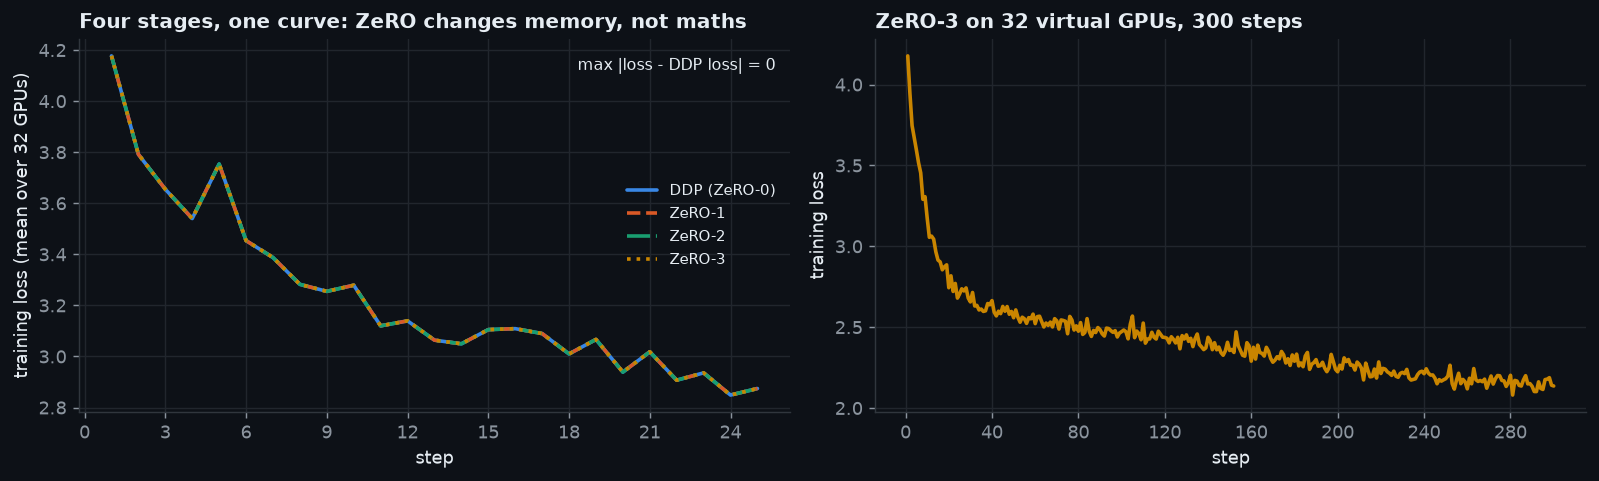

In [22]:
t0 = time.time()
long = run_training(RunConfig(stage=3, world=WORLD, steps=LONG_STEPS, seed=SEED,
                              warmup=max(5, LONG_STEPS // 20)), cfg, data, init)
shard_kb = [sum(t.numel() * 4 for (_, _, t) in st.values()) / 1024 for st in long.states]
model = TinyGPT(cfg).load_flat(long.module_flats(cfg))
prompt = data.encode("ROMEO:\n").unsqueeze(0)
sample = data.decode(model.generate(prompt, 300, generator=torch.Generator().manual_seed(SEED))[0].tolist())
print(f"{LONG_STEPS} steps in {time.time() - t0:.0f} s; loss {long.losses[0]:.3f} -> {long.losses[-1]:.3f}")
print(f"32 shard 'files' of {shard_kb[0]:.1f} KiB each -> one {sum(shard_kb) / 1024:.2f} MiB fp32 model\n")
print(sample)
assert long.losses[-1] < long.losses[0]
save_fig(zp.loss_curves({s: runs[s].losses for s in range(4)}, long.losses), "loss_curves.png")
RESULTS["training"] = {"steps": LONG_STEPS, "loss_first": long.losses[0],
                       "loss_last": long.losses[-1], "losses": long.losses,
                       "shard_kib": shard_kb[0], "sample": sample}

**What you should see:** the loss falling from ~4.2 (uniform over 65 characters is
ln 65 ≈ 4.17) and text that has Shakespeare's *shape* — names in capitals, line breaks,
short words — from a model no single virtual GPU ever held.

> **Takeaway.** Sharded training needs a consolidation step to become an ordinary
> checkpoint; a shard is a contiguous slice, so consolidation is concatenation.

## 16 — The out-of-memory ladder: predict first, then run

**Why.** The strongest test of a memory model is to predict failures. Give each of the 32
virtual GPUs a fixed capacity; predict from the formulas which stages fit; then run.

The prediction is written down **before** running: model states (the formula) +
activations (the same for every stage, measured once on a single device) + the largest
temporary buffer each stage creates. Capacities are placed at the geometric midpoints
between consecutive predictions, plus one above DDP and one below ZeRO-3.

activations per GPU (measured once): 1.430 MiB
predicted peak per GPU: DDP (ZeRO-0) 14.08 MiB, ZeRO-1 4.86 MiB, ZeRO-2 3.72 MiB, ZeRO-3 2.58 MiB



    capacity   DDP (ZeRO-0)         ZeRO-1         ZeRO-2         ZeRO-3
   17.60 MiB      fits    ✓      fits    ✓      fits    ✓      fits    ✓
    8.28 MiB       OOM    ✓      fits    ✓      fits    ✓      fits    ✓
    4.26 MiB       OOM    ✓       OOM    ✓      fits    ✓      fits    ✓
    3.10 MiB       OOM    ✓       OOM    ✓       OOM    ✓      fits    ✓
    1.94 MiB       OOM    ✓       OOM    ✓       OOM    ✓       OOM    ✓

example: vGPU 0 out of memory: tried to allocate 0.38 MiB for 'w:block3' (weights). Capacity 8.28 MiB; 8.20 MiB already held (weights 1.17, master 2.34, adam_m 2.34, adam_v 2.34); 0.07 MiB free.


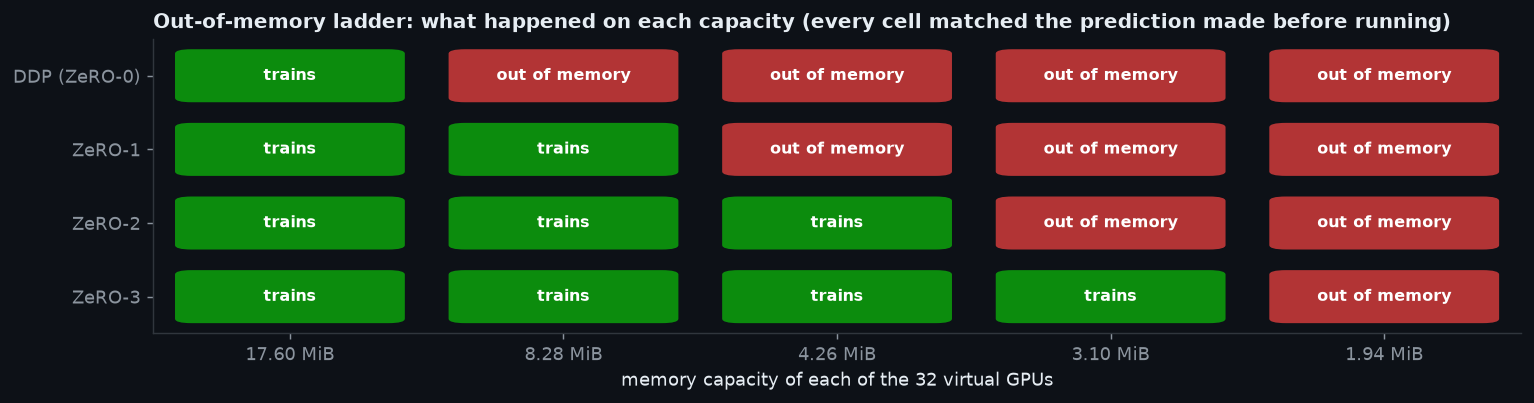

In [23]:
r_act = run_training(RunConfig(stage=0, world=1, steps=1, keep_state=False), cfg, data, init)
act_bytes = r_act.records[0][0]["cat_peak"]["activations"]
est = [estimate_peak_bytes(s, specs, WORLD, act_bytes) for s in range(4)]
caps = [int(est[0] * 1.25)] + [int(math.sqrt(est[i] * est[i + 1])) for i in range(3)] + \
       [int(est[3] * 0.75)]
predicted = {(s, i): est[s] <= c for s in range(4) for i, c in enumerate(caps)}
print(f"activations per GPU (measured once): {mib(act_bytes):.3f} MiB")
print("predicted peak per GPU: " + ", ".join(f"{STAGES[s].label} {mib(e):.2f} MiB"
                                              for s, e in enumerate(est)))
observed, messages = {}, {}
for i, c in enumerate(caps):
    for s in range(4):
        try:
            run_training(RunConfig(stage=s, world=WORLD, steps=1, capacity=c, keep_state=False),
                         cfg, data, init)
            observed[(s, i)] = True
        except VirtualOOMError as e:
            observed[(s, i)] = False
            messages[(s, i)] = str(e).splitlines()[0]
print(f"\n{'capacity':>12s} " + " ".join(f"{STAGES[s].label:>14s}" for s in range(4)))
for i, c in enumerate(caps):
    print(f"{mib(c):>8.2f} MiB " + " ".join(
        f"{('fits' if observed[(s, i)] else 'OOM'):>9s} {'✓' if observed[(s, i)] == predicted[(s, i)] else '✗':>4s}"
        for s in range(4)))
first_oom = next(messages[k] for k in sorted(messages))
print("\nexample:", first_oom)
save_fig(zp.oom_ladder(caps, predicted, observed), "oom_ladder.png")
matches = sum(observed[k] == predicted[k] for k in observed)
RESULTS["oom"] = {"act_bytes": act_bytes, "estimates": est, "capacities": caps,
                  "predicted": {f"{s}/{i}": v for (s, i), v in predicted.items()},
                  "observed": {f"{s}/{i}": v for (s, i), v in observed.items()},
                  "matches": matches, "total": len(observed), "example_message": first_oom}
assert matches == len(observed), "a prediction failed — reported honestly above"

**What you should see:** a staircase. The largest GPU fits everything; each step down
knocks out one more stage (DDP first), until only ZeRO-3 trains — and on the smallest
GPU even ZeRO-3 runs out. Every outcome matches the prediction.

> **Takeaway.** "Will it fit?" is arithmetic: model states from the formula, plus
> activations, plus the biggest transient buffer.

## 17 — GPU mode: is the ledger real?

**Why.** The ledger is bookkeeping; a skeptic should ask whether real memory agrees. Put
all 32 virtual GPUs on the one real GPU and compare the ledger with PyTorch's CUDA
allocator: (a) after building every GPU's model states, (b) while ZeRO-3 gathers and
frees a unit, and (c) in the middle of training — the change in memory from the start of
a step to the end of its forward (activations) and to the end of its backward
(gradients). The allocator rounds each tensor up to 512 bytes, so agreement is exact up
to that rounding. (On a machine without CUDA this section is skipped and says so.)

In [24]:
def cuda_audit(stage, world=WORLD, precision="bf16"):
    specs_ = make_units(cfg, world)
    gc.collect()                                        # free any previous run's engines first
    torch.cuda.synchronize()
    base = torch.cuda.memory_allocated()
    cl = VirtualCluster(world, device="cuda")
    box = {}

    def worker(rank, gpu, comm):
        eng = STAGES[stage](rank, gpu, comm, cfg, specs_, init, precision)
        comm.barrier()
        if rank == 0:
            torch.cuda.synchronize()
            box["static"] = torch.cuda.memory_allocated() - base
        comm.barrier()
        static = (gpu.current, len(gpu._held))
        dyn = None
        if stage == 3:                                  # gather one block, then free it
            u = eng.units[1]
            before = gpu.current
            eng._gather(u)
            torch.cuda.synchronize()
            comm.barrier()
            if rank == 0:
                box["gathered"] = torch.cuda.memory_allocated() - base
            comm.barrier()
            dyn = gpu.current - before
            eng._release(u)
            torch.cuda.synchronize()
            comm.barrier()
            if rank == 0:
                box["released"] = torch.cuda.memory_allocated() - base
            comm.barrier()
        return static, dyn

    out = cl.run(worker)
    del cl
    gc.collect()
    ledger = sum(o[0][0] for o in out)
    n_tensors = sum(o[0][1] for o in out)
    res = {"ledger_bytes": ledger, "cuda_bytes": box["static"], "tensors": n_tensors,
           "rounding_allowance": n_tensors * 512}
    if stage == 3:
        res.update(gather_ledger=sum(o[1] for o in out), gather_cuda=box["gathered"] - box["static"],
                   released_cuda=box["released"] - box["static"])
    return res


def cuda_step_audit(stage, world=WORLD, precision="bf16", steps=2):
    """Pause all GPUs at three points of the last step (start, end of forward, end of
    backward) and compare the allocator's change with the ledgers' change. Step 1 warms up
    cuBLAS workspaces, so they cancel out of the difference."""
    specs_ = make_units(cfg, world)
    gc.collect()
    cl = VirtualCluster(world, device="cuda")
    marks, ledgers = {}, [dict() for _ in range(world)]

    def worker(rank, gpu, comm):
        eng = STAGES[stage](rank, gpu, comm, cfg, specs_, init, precision)
        now = {"step": 0}

        def probe(label):
            if now["step"] != steps - 1:
                return
            comm.barrier()
            if rank == 0:
                torch.cuda.synchronize()
                marks[label] = torch.cuda.memory_allocated()
            ledgers[rank][label] = (gpu.current, len(gpu._held))
            comm.barrier()

        eng.probe = probe
        for st in range(steps):
            now["step"] = st
            eng.train_step(data.micro_batches(st, rank, world, 1, 1, cfg.block_size, SEED,
                                              "cuda"), 1e-3)
        return True

    cl.run(worker)
    del cl
    gc.collect()
    res = {}
    for label in ("end_of_forward", "end_of_backward"):
        d_cuda = marks[label] - marks["step_start"]
        d_ledger = sum(l[label][0] - l["step_start"][0] for l in ledgers)
        n_new = sum(max(0, l[label][1] - l["step_start"][1]) for l in ledgers)
        # allocator rounding (512 B per new tensor) + per GPU: the loss scalar, and the
        # input/target token tensors (allocated before the step, booked when autograd saves them)
        allowance = n_new * 512 + world * 3 * 512
        res[label] = dict(cuda=d_cuda, ledger=d_ledger, allowance=allowance)
    return res


if torch.cuda.is_available():
    try:                                                # native bf16 only (a T4 emulates it)
        native_bf16 = torch.cuda.is_bf16_supported(including_emulation=False)
    except TypeError:                                   # older torch: no emulation flag
        native_bf16 = torch.cuda.is_bf16_supported()
    prec = "bf16" if native_bf16 else "fp32"
    gpu_res = {"device": torch.cuda.get_device_name(0), "precision": prec, "stages": {}}
    for s in range(4):
        a = cuda_audit(s, precision=prec)
        diff = a["cuda_bytes"] - a["ledger_bytes"]
        print(f"{STAGES[s].label:14s} ledger (all 32 GPUs) {a['ledger_bytes']:>11,} B   "
              f"CUDA allocator {a['cuda_bytes']:>11,} B   difference {diff:>7,} B "
              f"(allowance {a['rounding_allowance']:,})")
        assert 0 <= diff <= a["rounding_allowance"]
        if s == 3:
            print(f"   ZeRO-3 gather of one block on all 32 GPUs: ledger +{a['gather_ledger']:,} B, "
                  f"CUDA +{a['gather_cuda']:,} B; after release CUDA returns to "
                  f"{a['released_cuda']:+,} B")
            assert 0 <= a["gather_cuda"] - a["gather_ledger"] <= WORLD * 512
            assert a["released_cuda"] == 0
        gpu_res["stages"][str(s)] = a
    print("\nmid-training (step 2), change since the step started, summed over 32 GPUs:")
    gpu_res["step_audit"] = {}
    for s in range(4):
        a = cuda_step_audit(s, precision=prec)
        gpu_res["step_audit"][str(s)] = a
        f, b = a["end_of_forward"], a["end_of_backward"]
        print(f"{STAGES[s].label:14s} end of forward (activations): ledger {f['ledger']:>+11,} B "
              f"CUDA {f['cuda']:>+11,} B | end of backward (gradients): ledger "
              f"{b['ledger']:>+11,} B CUDA {b['cuda']:>+11,} B")
        for x in (f, b):
            assert abs(x["cuda"] - x["ledger"]) <= x["allowance"], (s, x)
    # a short training run with all 32 virtual GPUs on the real GPU
    t0 = time.time()
    gl = {s: run_training(RunConfig(stage=s, world=WORLD, steps=3, device="cuda", precision=prec,
                                    keep_state=False), cfg, data, init).losses for s in (0, 3)}
    gpu_res["train_losses"] = gl
    gpu_res["seconds_for_6_steps"] = time.time() - t0
    print(f"\n3 steps on the real GPU: DDP losses {[round(x, 5) for x in gl[0]]}, "
          f"ZeRO-3 {[round(x, 5) for x in gl[3]]}  (identical: {gl[0] == gl[3]})")
    RESULTS["gpu_mode"] = gpu_res
else:
    print("No CUDA device here — skipped (the CPU run above is the reference).")
    RESULTS["gpu_mode"] = {"status": "skipped", "reason": "no CUDA device"}

DDP (ZeRO-0)   ledger (all 32 GPUs) 368,836,608 B   CUDA allocator 368,836,608 B   difference       0 B (allowance 393,216)


ZeRO-1         ledger (all 32 GPUs)  62,570,496 B   CUDA allocator  62,717,952 B   difference 147,456 B (allowance 393,216)


ZeRO-2         ledger (all 32 GPUs)  62,570,496 B   CUDA allocator  62,717,952 B   difference 147,456 B (allowance 393,216)


ZeRO-3         ledger (all 32 GPUs)  11,526,144 B   CUDA allocator  11,747,328 B   difference 221,184 B (allowance 393,216)
   ZeRO-3 gather of one block on all 32 GPUs: ledger +12,713,984 B, CUDA +12,713,984 B; after release CUDA returns to +0 B

mid-training (step 2), change since the step started, summed over 32 GPUs:


DDP (ZeRO-0)   end of forward (activations): ledger +48,046,208 B CUDA +48,070,656 B | end of backward (gradients): ledger +52,690,944 B CUDA +52,690,944 B


ZeRO-1         end of forward (activations): ledger +48,046,208 B CUDA +48,070,656 B | end of backward (gradients): ledger +52,690,944 B CUDA +52,690,944 B


ZeRO-2         end of forward (activations): ledger +48,046,208 B CUDA +48,070,656 B | end of backward (gradients): ledger  +1,646,592 B CUDA  +1,720,320 B


ZeRO-3         end of forward (activations): ledger +48,046,208 B CUDA +48,070,656 B | end of backward (gradients): ledger  +1,646,592 B CUDA  +1,720,320 B



3 steps on the real GPU: DDP losses [4.17722, 3.79149, 3.65477], ZeRO-3 [4.17722, 3.79149, 3.65477]  (identical: True)


**What you should see:** ledger and allocator agreeing to within the allocator's 512-byte
rounding for every stage; a ZeRO-3 gather that adds exactly one block's bf16 weights per
GPU, and a release that gives every byte back; and mid-step activation and gradient growth
that the ledger tracks to within a few KiB across all 32 GPUs.

> **Takeaway.** Shrinking a storage to zero really returns the memory — that is the
> whole mechanism behind ZeRO-3/FSDP parameter freeing.

## 18 — The same engine on real `torch.distributed`

**Why.** Threads and shared slots could hide a mistake that real collectives would expose.
`tools/gloo_check.py` runs the *same* `ZeRO1` class in separate OS processes over
PyTorch's gloo backend (with a small adapter that implements the same communicator
interface with `dist.reduce_scatter_tensor` / `dist.all_gather_into_tensor`), then
compares with the thread simulator at the same N. Gloo sums in a different order, so the
check is `allclose`, not bit-equality. Each process loads PyTorch, so the number of
processes adapts to free RAM.

In [25]:
from tools.gloo_check import run_gloo_check

gloo = run_gloo_check(steps=3)
print(json.dumps({k: v for k, v in gloo.items() if k not in ("stderr",)}, indent=1, default=str)[:1500])
assert gloo["status"] in ("ok", "skipped"), gloo      # "failed", "timeout", "mismatch" stop here
if gloo["status"] == "ok":
    assert gloo["allclose"]
RESULTS["gloo"] = gloo

{
 "status": "ok",
 "world": 2,
 "steps": 3,
 "ram_available_gb": 0.92,
 "config": {
  "vocab_size": 65,
  "n_embd": 64,
  "n_layer": 2,
  "n_head": 2,
  "block_size": 32,
  "seed": 1337,
  "lr": 0.003,
  "warmup": 5,
  "micro_bsz": 1,
  "grad_accum": 1,
  "precision": "fp32",
  "stage": 1
 },
 "primitives": {
  "reduce_scatter": "reduce_scatter_tensor",
  "all_gather": "all_gather_into_tensor",
  "all_reduce": "all_reduce"
 },
 "fallbacks": {},
 "losses_gloo": [
  4.215559005737305,
  4.133907794952393,
  4.071094036102295
 ],
 "losses_sim": [
  4.215559005737305,
  4.133907794952393,
  4.071094036102295
 ],
 "max_abs_weight_diff": 0.0,
 "max_abs_loss_diff": 0.0,
 "allclose": true,
 "bit_exact_weights": true,
 "comm_bytes_per_rank": {
  "gloo": [
   {
    "grad_sync:reduce_scatter": 656640,
    "loss:all_reduce": 12,
    "param_gather:all_gather": 656640
   },
   {
    "grad_sync:reduce_scatter": 656640,
    "loss:all_reduce": 12,
    "param_gather:all_gather": 656640
   }
  ],
  "sim

**What you should see:** `status: ok`, the gloo primitives that were used, and weights and
losses that agree to ~1e-7 (bit-exact at N = 2, where each element sees one addition). The
per-GPU byte counts match too — but both sides apply the same ring cost model, so that
confirms the *sequence* of collectives, not bytes on the wire; the weights are the evidence.

> **Takeaway.** The communicator interface is the only thing that changed between threads
> and processes; the ZeRO code is identical.

## 19 — Real hardware: which stage fits 7B, 13B, 70B on 32 GPUs?

**Why.** The toy model proves the mechanics; the formulas carry them to real sizes. For
32 GPUs (4 nodes × 8) with 80 GB each: model states per GPU, activations (Korthikanti et
al. 2022; micro-batch 1 at the model's context length), and time per step from an α-β
model — compute 6ΨD at 40% MFU vs communication over the inter-node link, which is the
bottleneck of a 4-node ring. Hardware constants and sources are in `zero_theory.HARDWARE`.

def overlap_threshold_tokens(stage, hw, mfu=0.4, bytes_per_elem=2, n=None, recompute=False,
                             network="per_nic") -> float:
    """Tokens per GPU per step at which communication time equals compute time
    (bandwidth term only). More tokens than this and communication can hide.

    Set the two times equal:
        comm    = v * Ψ * bytes / BW                  v = 2 (DDP, ZeRO-1/2) or 3 (ZeRO-3)
        compute = 6 * Ψ * T / (peak * MFU)
        =>  T*  = v * bytes * peak * MFU / (6 * BW)

    Ψ cancels. Every parameter is sent a fixed number of times per step and costs a
    fixed 6 FLOPs per token, so both sides grow linearly with model size. A bigger model
    does not hide communication any better; only more tokens per GPU does. And a faster
    GPU (bigger peak) needs MORE tokens, because compute shrinks while the network
    stays the same.

    n=None uses the large-N limit (no (N-1)/N factor) and the inter-node bandwidth.
    Passing n applies (N-1)/N and picks NVLink when N fits in one node.

    Caveat: this assumes communication can overlap the whole step. Gradient sync can
    only start once backward produces gradients (about 2/3 of the compute), so in
    practice you need somewhat more tokens.
    """
    hw = _hw(hw)
    if n is None:
        bw, rho = effective_bandwidth(hw, hw["gpus_per_node"] + 1, network), 1.0
    else:
        bw, rho = effective_bandwidth(hw, n, network), ring_factor(n)
    return (comm_volume_psi(stage) * rho * bytes_per_elem * hw["peak_bf16_flops"] * mfu
            / (flops_per_token_factor(recompute) * bw))


32 × A100-80GB — micro-batch 1 at each model's context length, selective recompute, one NIC per GPU (conservative)
      model     variant  states_gb  act_gb  total_gb  fits_80GB  fits_with  compute_s  comm_s  comm_over_compute
-----------  ----------  ---------  ------  --------  ---------  ---------  ---------  ------  -----------------
   GPT-2 XL         DDP       24.9    2.67      27.6        yes       none     0.0767   0.272               3.55
   GPT-2 XL      ZeRO-1       6.81    2.67      9.49        yes       none     0.0767   0.272               3.55
   GPT-2 XL      ZeRO-2        3.8    2.67      6.47        yes       none     0.0767   0.272               3.55
   GPT-2 XL      ZeRO-3      0.779    2.67      3.45        yes       none     0.0767   0.409               5.33
   GPT-2 XL        HSDP       3.12    2.67      5.79        yes       none     0.0767  0.0641              0.836
   GPT-2 XL  ZeRO++ hpZ       1.17    2.67      3.84        yes       none     0.0767   0.285

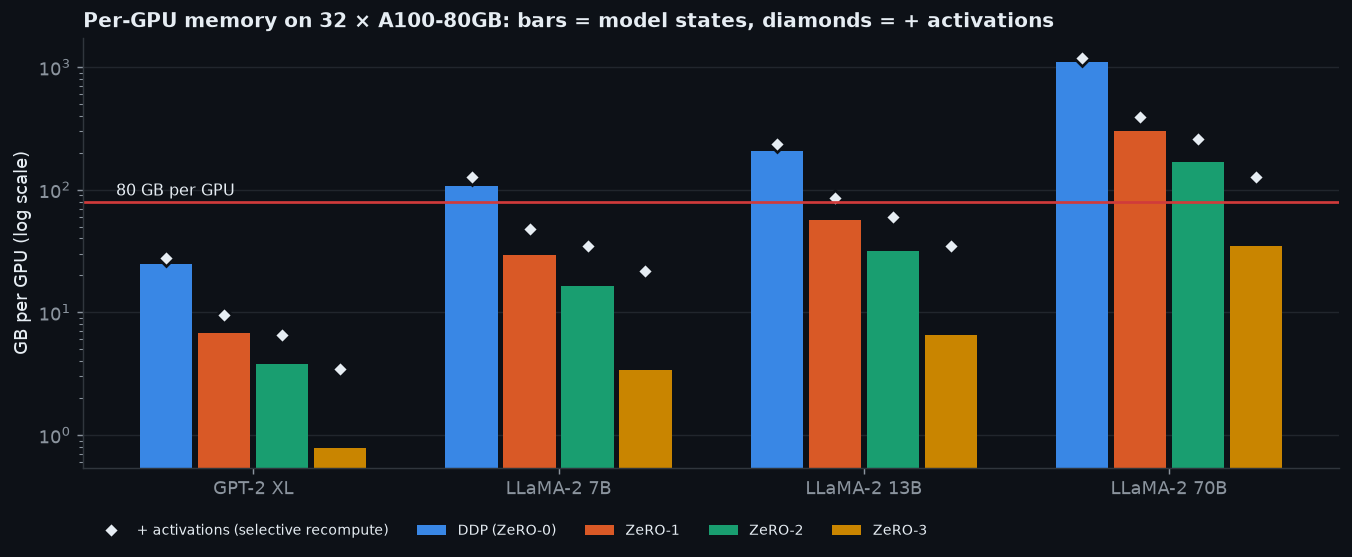

A100-80GB  network=per_nic : communication can hide behind compute above ~3,328 tokens/GPU/step (DDP, ZeRO-1, ZeRO-2), ~4,992 (ZeRO-3)
A100-80GB  network=rail    : communication can hide behind compute above ~416 tokens/GPU/step (DDP, ZeRO-1, ZeRO-2), ~624 (ZeRO-3)
H100-80GB  network=per_nic : communication can hide behind compute above ~5,275 tokens/GPU/step (DDP, ZeRO-1, ZeRO-2), ~7,912 (ZeRO-3)
H100-80GB  network=rail    : communication can hide behind compute above ~659 tokens/GPU/step (DDP, ZeRO-1, ZeRO-2), ~989 (ZeRO-3)
HSDP vs ZeRO-3 (7B, 32 × A100): 4.0× the model states (N/g = 32/8), 7.0× less modelled communication time


In [26]:
show_code(zt.overlap_threshold_tokens)
RESULTS["real_hardware"] = {}
for hw in zt.HARDWARE:
    rows = zt.real_hardware_rows(n_gpus=WORLD, hw=hw)
    RESULTS["real_hardware"][hw] = rows
    print()
    print(f"32 × {hw} — micro-batch 1 at each model's context length, selective recompute, "
          f"one NIC per GPU (conservative)")
    print(zt.rows_to_text(rows))
save_fig(zp.real_hardware(RESULTS["real_hardware"]["A100-80GB"], 80,
                          "Per-GPU memory on 32 × A100-80GB: bars = model states, "
                          "diamonds = + activations"), "real_hardware.png")
RESULTS["overlap_tokens"] = {}
for hw in zt.HARDWARE:
    for net in zt.NETWORKS:
        v = {s: zt.overlap_threshold_tokens(s, hw, network=net) for s in range(4)}
        RESULTS["overlap_tokens"][f"{hw}/{net}"] = v
        print(f"{hw:10s} network={net:8s}: communication can hide behind compute above "
              f"~{v[0]:,.0f} tokens/GPU/step (DDP, ZeRO-1, ZeRO-2), ~{v[3]:,.0f} (ZeRO-3)")
seventy = {r["variant"]: r for r in RESULTS["real_hardware"]["A100-80GB"] if r["model"] == "LLaMA-2 70B"}
assert seventy["ZeRO-3"]["states_gb"] < 80 < seventy["ZeRO-2"]["states_gb"]
seven = {r["variant"]: r for r in RESULTS["real_hardware"]["A100-80GB"] if r["model"] == "LLaMA-2 7B"}
hsdp = dict(states_ratio=seven["HSDP"]["states_gb"] / seven["ZeRO-3"]["states_gb"],
            comm_time_ratio=seven["ZeRO-3"]["comm_s"] / seven["HSDP"]["comm_s"])
RESULTS["hsdp_vs_zero3_7b"] = hsdp
print(f"HSDP vs ZeRO-3 (7B, 32 × A100): {hsdp['states_ratio']:.1f}× the model states "
      f"(N/g = 32/8), {hsdp['comm_time_ratio']:.1f}× less modelled communication time")

**What you should see:**
* LLaMA-2 7B fits from ZeRO-1 on; 13B needs ZeRO-2; for 70B only ZeRO-3 gets the *model
  states* under 80 GB (34.5 GB) — and with activations it also needs full recomputation.
  (`fits_with` says which recompute mode is needed.) HSDP — shard inside a node,
  replicate across nodes — holds N/g = 4× the model states of ZeRO-3, but only the 1/g
  shard's gradients cross the slow inter-node link, so its modelled communication time
  drops several-fold (printed above).
* The overlap threshold does not depend on model size (Ψ cancels), and a *faster* GPU
  needs *more* tokens per step to hide its communication. `per_nic` assumes every byte
  crosses one 25/50 GB/s NIC (conservative); `rail` assumes NCCL spreads the ring over all
  8 NICs of a node, as it does on DGX systems — both are shown because real clusters sit
  in between.

> **Takeaway.** Memory decides which stage is *possible*; tokens per GPU per step decide
> whether its communication is *free*.

## 20 — Revision sheet

| | DDP (ZeRO-0) | ZeRO-1 | ZeRO-2 | ZeRO-3 |
|---|---|---|---|---|
| sharded | nothing | optimizer states | + gradients | + weights |
| memory / GPU | 16Ψ | 4Ψ + 12Ψ/N | 2Ψ + 14Ψ/N | 16Ψ/N |
| gradient sync | all-reduce | reduce-scatter | reduce-scatter (per unit, early) | reduce-scatter |
| after the step | — | all-gather weights | all-gather weights | — (weights stay sharded) |
| traffic / step | 2Ψ | 2Ψ | 2Ψ | 3Ψ |
| with G micro-batches | 2Ψ | 2Ψ | (G+1)Ψ | 3GΨ |
| fwd/bwd FLOPs | F | F | F | F |
| optimizer work / GPU | Ψ | Ψ/N | Ψ/N | Ψ/N |
| DeepSpeed / FSDP | stage 0 / `NO_SHARD` | stage 1 | stage 2 / `SHARD_GRAD_OP` | stage 3 / `FULL_SHARD` |

**Pitfalls worth remembering**
* PyTorch's `ZeroRedundancyOptimizer` shards the optimizer but all-reduces gradients and
  then broadcasts weights: 3Ψ of traffic, not ZeRO-1's 2Ψ.
* DeepSpeed (bf16) and Megatron keep fp32 gradient buffers: 4Ψ of gradients, not 2Ψ.
* Global-norm gradient clipping under ZeRO-2/3 needs one extra all-reduce (of a scalar:
  each GPU sums the squares of its slice).
* ZeRO never shards activations or temporary buffers; checkpointing, ZeRO-R activation
  partitioning, and sequence parallelism do.
* ZeRO-3's many small collectives are latency-bound unless the next unit is prefetched.

**Self-quiz** (answers in the README):
1. Where do the 16 bytes per parameter go? 2. Why does ZeRO-1/2 communicate no more than
DDP? 3. Where does ZeRO-3's extra Ψ come from? 4. Why does ZeRO-2 communicate every
micro-batch? 5. What does ZeRO not shard? 6. How does FSDP free weights without breaking
autograd? 7. Why does all-reduce = reduce-scatter + all-gather matter? 8. How do you clip
by global norm when gradients are sharded? 9. How do you save and load a ZeRO-3
checkpoint? 10. When does communication hide behind compute? 11. `ZeroRedundancyOptimizer`
vs ZeRO-1? 12. ZeRO vs tensor vs pipeline parallelism — what does each split?

## 21 — Save the run

In [27]:
RESULTS["run"] = {"quick_run": QUICK_RUN, "torch": torch.__version__,
                  "python": platform.python_version(), "cpu_threads": os.cpu_count(),
                  "world": WORLD, "steps": STEPS, "seed": SEED,
                  "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                  "seconds_total": round(time.time() - T_START, 1)}
with open(os.path.join(ASSET_DIR, "results.json"), "w", encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=1, default=lambda o: o.__dict__ if hasattr(o, "__dict__") else str(o))
print(f"RUN STAMP {RESULTS['run']['timestamp']} · quick={QUICK_RUN} · "
      f"{RESULTS['run']['seconds_total']} s · wrote {ASSET_DIR}/results.json")

RUN STAMP 2026-09-20 00:26:06 · quick=False · 729.3 s · wrote assets/results.json
